In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import utils  
from src.config import Config as cfg  



# -------------------------------------------------------


from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



sys.path contains: /home/ismail/Documents/projects/ml-projects/x42


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Load Data

In [2]:

df_train = pd.read_csv("../train.csv")
X_test = pd.read_csv("../test.csv")




df_train.head()

,id,sudden_fever,headache,mouth_bleed,nose_bleed,muscle_pain,joint_pain,vomiting,rash,diarrhea,...,breathing_restriction,toe_inflammation,finger_inflammation,lips_irritation,itchiness,ulcers,toenail_loss,speech_problem,bullseye_rash,prognosis
0,0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Lyme_disease
1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Tungiasis
2,2,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,Lyme_disease
3,3,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Zika
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,Rift_Valley_fever


In [3]:
# clean columns

# import re
# def clean_feature_names(data):
#     cleaned_columns = []
#     for column in data.columns:
#         cleaned_column = re.sub('[^A-Za-z0-9_]+', '', column)
#         cleaned_columns.append(cleaned_column)
#     data.columns = cleaned_columns
#     return data


# df_train = clean_feature_names(df_train)
# X_test = clean_feature_names(X_test)
# df_train.columns

In [4]:
target = cfg.TARGET
X_train = df_train.drop(columns=[target]) # delete id if exists
y_train = df_train[target]

X_train_original = X_train.copy()
X_test_original = X_test.copy()
y_train_original = y_train.copy()


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (707, 65)
X_test shape: (303, 65)


In [7]:
X_train.head()

,id,sudden_fever,headache,mouth_bleed,nose_bleed,muscle_pain,joint_pain,vomiting,rash,diarrhea,...,lymph_swells,breathing_restriction,toe_inflammation,finger_inflammation,lips_irritation,itchiness,ulcers,toenail_loss,speech_problem,bullseye_rash
0,0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
3,3,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


In [6]:
X_test.head()

,id,sudden_fever,headache,mouth_bleed,nose_bleed,muscle_pain,joint_pain,vomiting,rash,diarrhea,...,lymph_swells,breathing_restriction,toe_inflammation,finger_inflammation,lips_irritation,itchiness,ulcers,toenail_loss,speech_problem,bullseye_rash
0,707,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,708,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,709,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,710,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,711,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Folds For Stacking**

In [7]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# # ['Survived']
# # Assume y_train is already loaded
# y = y_train.values  # make sure it's a 1D array

# # Number of folds
# n_splits = 5
# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# # Precompute fold indices
# folds = []
# for train_idx, val_idx in skf.split(np.zeros(len(y)), y):
#     folds.append((train_idx, val_idx))


# folds_array = np.array(folds, dtype=object)

# # Save folds to disk using pickle
# np.save('fold_indices.npy', folds_array)
# print("Fold indices saved!")


In [8]:
def print_duplicates(df, name):
    dup_count = df.duplicated().sum()
    total = len(df)
    print(f"{name}: {dup_count} duplicate rows ({dup_count / total:.2%})")

print_duplicates(df_train, "Train")
print_duplicates(X_test, "Test")


Train: 0 duplicate rows (0.00%)
Test: 0 duplicate rows (0.00%)


In [9]:
X_train.columns

Index(['id', 'sudden_fever', 'headache', 'mouth_bleed', 'nose_bleed',
       'muscle_pain', 'joint_pain', 'vomiting', 'rash', 'diarrhea',
       'hypotension', 'pleural_effusion', 'ascites', 'gastro_bleeding',
       'swelling', 'nausea', 'chills', 'myalgia', 'digestion_trouble',
       'fatigue', 'skin_lesions', 'stomach_pain', 'orbital_pain', 'neck_pain',
       'weakness', 'back_pain', 'weight_loss', 'gum_bleed', 'jaundice', 'coma',
       'diziness', 'inflammation', 'red_eyes', 'loss_of_appetite',
       'urination_loss', 'slow_heart_rate', 'abdominal_pain',
       'light_sensitivity', 'yellow_skin', 'yellow_eyes', 'facial_distortion',
       'microcephaly', 'rigor', 'bitter_tongue', 'convulsion', 'anemia',
       'cocacola_urine', 'hypoglycemia', 'prostraction', 'hyperpyrexia',
       'stiff_neck', 'irritability', 'confusion', 'tremor', 'paralysis',
       'lymph_swells', 'breathing_restriction', 'toe_inflammation',
       'finger_inflammation', 'lips_irritation', 'itchiness', 'ul

In [10]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()



from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)


# y_train_int = y_train.astype(int)
y_train_int = y_train_enc


all_cols = set(X_train.columns)
used_cols = set(cat_cols + num_cols)

leftover_cols = list(all_cols - used_cols)
print("Columns not in cat_cols or num_cols:", leftover_cols)

Columns not in cat_cols or num_cols: []


In [9]:
# Combining Customerid , Surname , Geography , and Gender , Estimated Slaray  and Making New Column in both Data Frames 
X_train['Sur_Geo_Gend_Sal'] = X_train['CustomerId'].astype('str')+X_train['Surname']+X_train['Geography']+X_train['Gender']+np.round(X_train.EstimatedSalary).astype('str')
X_test['Sur_Geo_Gend_Sal'] = X_test['CustomerId'].astype('str')+X_test['Surname']+X_test['Geography']+X_test['Gender']+np.round(X_test.EstimatedSalary).astype('str')




*The `get_vectors` function takes two DataFrames `(df_train and df_test)`, and a specified column name (`col_name`). It performs the following steps:

1. Utilizes the TfidfVectorizer to transform the text data in the specified column into TF-IDF vectors, limiting the features to a maximum of 1000.

2. Applies dimensionality reduction using TruncatedSVD with 3 components to further transform the TF-IDF vectors.

3. Converts the transformed vectors into DataFrames (tfidf_df_train and tfidf_df_test).

4. Names the columns in the new DataFrames with a combination of the original column name and additional information.

5. Resets the index of the original DataFrames before concatenation.

6. Concatenates the transformed features with the original data along the columns.

7. Returns the modified training and testing DataFrames.

This function effectively combines TF-IDF vectorization and dimensionality reduction to enhance the original DataFrames with transformed features, facilitating machine learning tasks that involve text data.

*The TF-IDF matrix can be high-dimensional, and TfidfVectorizer helps reduce this dimensionality, making it computationally more efficient and often improving model performance.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
def get_vectors(df_train,df_test,col_name):

    vectorizer = TfidfVectorizer(max_features=1000)
    vectors_train = vectorizer.fit_transform(df_train[col_name])
    vectors_test = vectorizer.transform(df_test[col_name])
    
    #Dimensionality Reduction Using SVD ( Singular Value Decompostion)
    svd = TruncatedSVD(3)
    x_sv_train = svd.fit_transform(vectors_train)
    x_sv_test = svd.transform(vectors_test)

    # Convert to DataFrames
    tfidf_df_train = pd.DataFrame(x_sv_train)
    tfidf_df_test = pd.DataFrame(x_sv_test)

    # Naming columns in the new DataFrames
    cols = [(col_name + "_tfidf_" + str(f)) for f in tfidf_df_train.columns.to_list()]
    tfidf_df_train.columns = cols
    tfidf_df_test.columns = cols

    # Reset the index of the DataFrames before concatenation
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    # Concatenate transformed features with original data
    df_train = pd.concat([df_train, tfidf_df_train], axis="columns")
    df_test = pd.concat([df_test, tfidf_df_test], axis="columns")
    return df_train,df_test


In [11]:
X_train,X_test = get_vectors(X_train,X_test,'Surname')
X_train,X_test = get_vectors(X_train,X_test,'Sur_Geo_Gend_Sal')

,Product ID,Type
0,L50096,L
1,M20343,M
2,L49454,L
3,L53355,L
4,M24050,M
...,...,...
136424,M22284,M
136425,H38017,H
136426,L54690,L
136427,L53876,L


In [13]:
X_train['Sur_Geo_Gend_Sal_tfidf_0'].nunique()

1056


### Class Weights

This code is preparing class weights to handle imbalanced classification problems.

u can then pass it as 
```
model = HistGradientBoostingClassifier(class_weight=class_weights_dict)
```


**Rule of thumb**

- For tree-based models (LightGBM, CatBoost, HistGB): <mark>raw weights</mark> usually work best.
- For linear models or neural networks: <mark>normalized weights</mark> can help stabilize training.

In [11]:
import numpy as np
import pandas as pd

def compute_class_weights(y, return_normalized=True):
    """
    Compute class weights for imbalanced classification problems.

    Parameters
    ----------
    y : array-like or pd.Series
        Target labels (categorical or numeric).
    return_normalized : bool, default=True
        If True, also return normalized weights (sum to number of classes).

    Returns
    -------
    y_numeric : np.ndarray
        Numeric mapping of the original classes.
    class_to_index : dict
        Mapping from original classes to numeric indices.
    class_counts : np.ndarray
        Number of samples in each class.
    raw_class_weights : np.ndarray
        Raw computed weights: total_samples / (num_classes * class_count).
    normalized_class_weights : np.ndarray or None
        Normalized weights (sum to number of classes), or None if return_normalized=False.
    class_weights_dict : dict
        Mapping from original classes to raw weights (ready for model use).
    normalized_class_weights_dict : dict or None
        Mapping from original classes to normalized weights, or None if return_normalized=False.
    """

    y = np.array(y)
    classes = np.unique(y)

    # Map original classes to numeric indices
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}
    y_numeric = np.array([class_to_index[cls] for cls in y])

    # Count samples per class
    class_counts = np.bincount(y_numeric)
    total_samples = len(y_numeric)
    n_classes = len(classes)

    # Raw class weights
    raw_class_weights = total_samples / (n_classes * class_counts)
    class_weights_dict = {cls: w for cls, w in zip(classes, raw_class_weights)}

    # Normalized weights (optional)
    normalized_class_weights = None
    normalized_class_weights_dict = None
    if return_normalized:
        normalized_class_weights = raw_class_weights / raw_class_weights.sum() * n_classes
        normalized_class_weights_dict = {cls: w for cls, w in zip(classes, normalized_class_weights)}

    return (
        y_numeric,
        class_to_index,
        class_counts,
        raw_class_weights,
        normalized_class_weights,
        class_weights_dict,
        normalized_class_weights_dict
    )

In [12]:
# Compute class weights
(
    y_numeric,
    class_to_index,
    class_counts,
    raw_weights,
    norm_weights,
    raw_weights_dict,
    norm_weights_dict
) = compute_class_weights(y_train, return_normalized=True)

print("Class counts:", class_counts)
print("Raw weights dict:", raw_weights_dict)
print("Normalized weights dict:", norm_weights_dict)




Class counts: [66 63 81 52 48 53 70 70 85 61 58]
Raw weights dict: {'Chikungunya': 0.9738292011019284, 'Dengue': 1.02020202020202, 'Japanese_encephalitis': 0.7934904601571269, 'Lyme_disease': 1.236013986013986, 'Malaria': 1.3390151515151516, 'Plague': 1.2126929674099485, 'Rift_Valley_fever': 0.9181818181818182, 'Tungiasis': 0.9181818181818182, 'West_Nile_fever': 0.7561497326203208, 'Yellow_Fever': 1.053651266766021, 'Zika': 1.1081504702194358}
Normalized weights dict: {'Chikungunya': 0.945502054747762, 'Dengue': 0.9905259621167031, 'Japanese_encephalitis': 0.7704090816463247, 'Lyme_disease': 1.200060300256775, 'Malaria': 1.3000653252781729, 'Plague': 1.1774176530821188, 'Rift_Valley_fever': 0.8914733659050329, 'Tungiasis': 0.8914733659050329, 'West_Nile_fever': 0.734154536627674, 'Yellow_Fever': 1.0230022231697098, 'Zika': 1.0759161312646948}


In [13]:
X_train

,id,sudden_fever,headache,mouth_bleed,nose_bleed,muscle_pain,joint_pain,vomiting,rash,diarrhea,...,lymph_swells,breathing_restriction,toe_inflammation,finger_inflammation,lips_irritation,itchiness,ulcers,toenail_loss,speech_problem,bullseye_rash
0,0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
3,3,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,702,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
703,703,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
704,704,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
705,705,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Drop qualitative/redundant/collinear/high cardinality features safely
X_train.drop([cfg.ID], axis=1, inplace=True, errors='ignore')
X_test.drop([], axis=1, inplace=True, errors='ignore')


In [15]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train_original.to_csv('../data/y_train.csv', index=False)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_original shape:", y_train_original.shape)

X_train shape: (707, 64)
X_test shape: (303, 65)
y_train_original shape: (707,)


In [16]:
y_train.shape

(707,)

# One-Hot Encoding

In [17]:
from sklearn.preprocessing import OneHotEncoder

# Select categorical features
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Create encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on train and transform train
X_train_encoded = encoder.fit_transform(X_train[categorical_features])

# Transform test
X_test_encoded = encoder.transform(X_test[categorical_features])

# Convert to DataFrame with proper column names
encoded_cols = encoder.get_feature_names_out(categorical_features)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Combine with numeric features
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
X_train_encoded = pd.concat([X_train[numeric_features], X_train_encoded_df], axis=1)
X_test_encoded = pd.concat([X_test[numeric_features], X_test_encoded_df], axis=1)

print("X_train shape:", X_train_encoded.shape)
print("X_test shape:", X_test_encoded.shape)

import re
# Clean column names (in case not done yet)
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    cols = pd.Series(df.columns)
    for dup in cols[cols.duplicated()].unique():
        cols[cols == dup] = [f"{dup}_{i}" if i != 0 else dup for i in range(sum(cols == dup))]
    df.columns = cols
    return df

X_train_encoded = clean_column_names(X_train_encoded.copy())
X_test_encoded = clean_column_names(X_test_encoded.copy())

X_train shape: (707, 64)
X_test shape: (303, 64)


In [18]:
test_ids = X_test[cfg.ID]
X_test_encoded[cfg.ID] = test_ids.values

X_train_encoded.to_csv('../data/X_train_encoded.csv', index=False)
X_test_encoded.to_csv('../data/X_test_encoded.csv', index=False)
y_train_original.to_csv('../data/y_train.csv', index=False)




print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)
print("y_train_original shape:", y_train_original.shape)

X_train_encoded shape: (707, 64)
X_test_encoded shape: (303, 65)
y_train_original shape: (707,)


ip                       category
app                      category
device                   category
os                       category
channel                  category
click_time         datetime64[ns]
attributed_time    datetime64[ns]
dtype: object

# Time patterns

In [15]:
X_train_time = X_train.copy()
X_train_time['is_attributed'] = y_train.copy()
X_test_time = X_test.copy()

**Extracting time information**

In [16]:
X_train_time['day'] = X_train_time['click_time'].dt.day.astype('uint8')
X_train_time['hour'] = X_train_time['click_time'].dt.hour.astype('uint8')
X_train_time['minute'] = X_train_time['click_time'].dt.minute.astype('uint8')
X_train_time['second'] = X_train_time['click_time'].dt.second.astype('uint8')
X_train_time.head()


,ip,app,device,os,channel,click_time,is_attributed,day,hour,minute,second
0,83230,3,1,13,379,2017-11-06 14:32:21,0,6,14,32,21
1,17357,3,1,19,379,2017-11-06 14:33:34,0,6,14,33,34
2,35810,3,1,13,379,2017-11-06 14:34:12,0,6,14,34,12
3,45745,14,1,13,478,2017-11-06 14:34:52,0,6,14,34,52
4,161007,3,1,13,379,2017-11-06 14:35:08,0,6,14,35,8


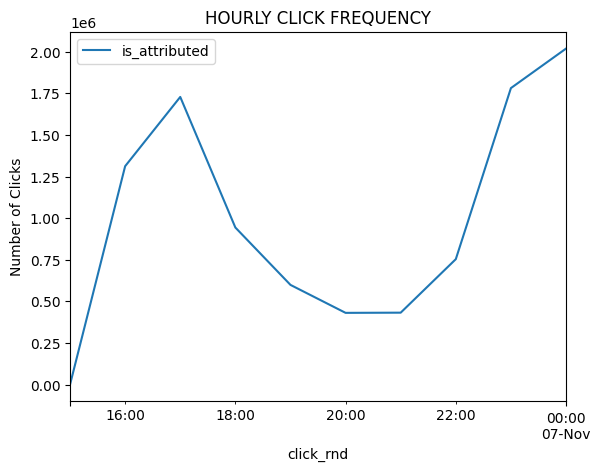

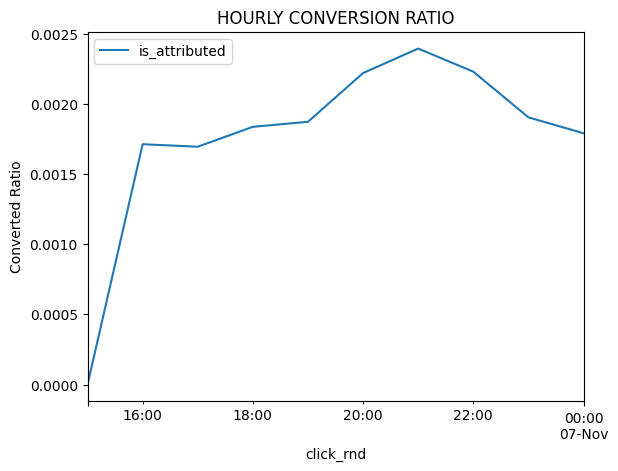

In [50]:
#round the time to nearest hour
X_train_time['click_rnd']=X_train_time['click_time'].dt.round('H')  

#check for hourly patterns
X_train_time[['click_rnd','is_attributed']].groupby(['click_rnd'], as_index=True).count().plot()
plt.title('HOURLY CLICK FREQUENCY');
plt.ylabel('Number of Clicks');

X_train_time[['click_rnd','is_attributed']].groupby(['click_rnd'], as_index=True).mean().plot()
plt.title('HOURLY CONVERSION RATIO');
plt.ylabel('Converted Ratio');

In [55]:


#extract hour as a feature
X_train_time['click_hour']=X_train_time['click_time'].dt.hour



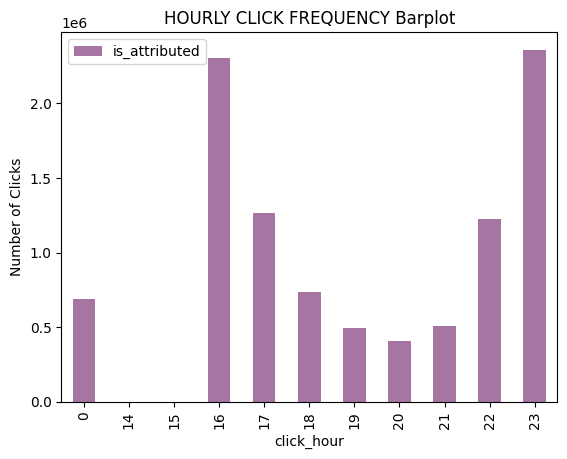

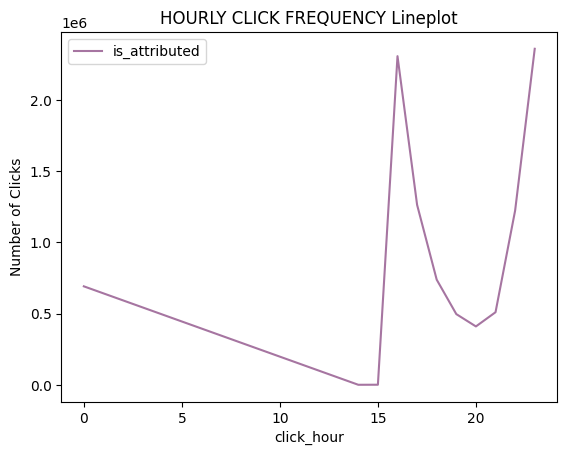

In [ ]:
# number of clicks by hour:
X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).count().plot(kind='bar', color='#a675a1')
plt.title('HOURLY CLICK FREQUENCY Barplot');
plt.ylabel('Number of Clicks');

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).count().plot(color='#a675a1')
plt.title('HOURLY CLICK FREQUENCY Lineplot');
plt.ylabel('Number of Clicks');


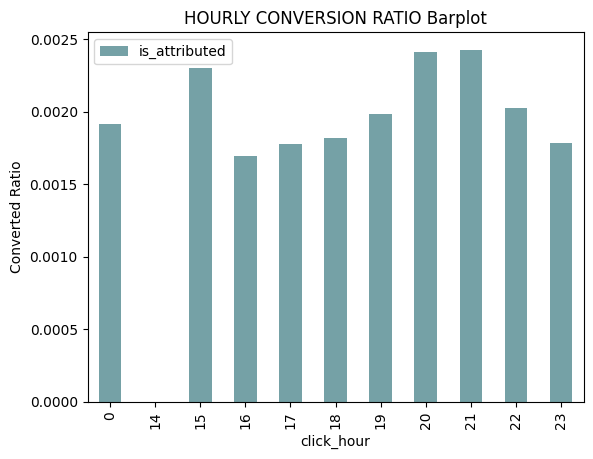

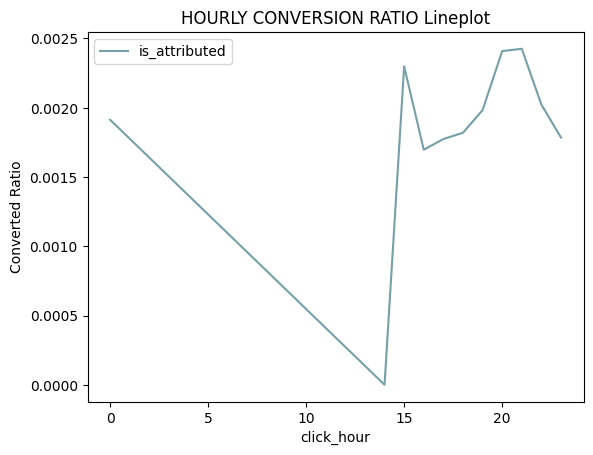

In [ ]:


# number of conversions by hours:

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).mean().plot(kind='bar', color='#75a1a6')
plt.title('HOURLY CONVERSION RATIO Barplot');
plt.ylabel('Converted Ratio');

X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=True).mean().plot( color='#75a1a6')
plt.title('HOURLY CONVERSION RATIO Lineplot');
plt.ylabel('Converted Ratio');


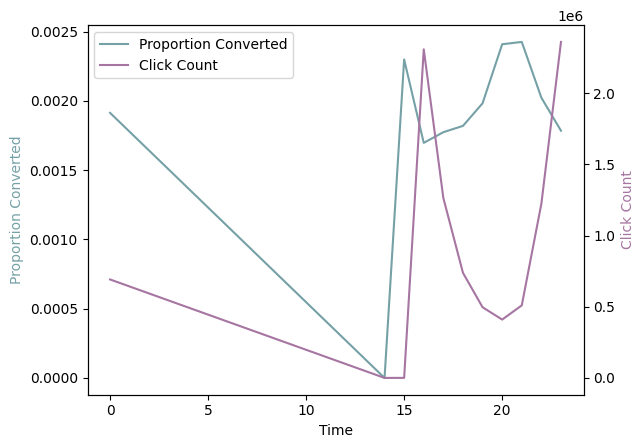

In [ ]:
# 

# let's overlay the two graphs to see if patterns correlate in any way


group = X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=False).mean()
x = group['click_hour']
ymean = group['is_attributed']
group = X_train_time[['click_hour','is_attributed']].groupby(['click_hour'], as_index=False).count()
ycount = group['is_attributed']


fig = plt.figure()
host = fig.add_subplot(111)

par1 = host.twinx()

host.set_xlabel("Time")
host.set_ylabel("Proportion Converted")
par1.set_ylabel("Click Count")

#color1 = plt.cm.viridis(0)
#color2 = plt.cm.viridis(0.5)
color1 = '#75a1a6'
color2 = '#a675a1'

p1, = host.plot(x, ymean, color=color1,label="Proportion Converted")
p2, = par1.plot(x, ycount, color=color2, label="Click Count")

lns = [p1, p2]
host.legend(handles=lns, loc='best')

host.yaxis.label.set_color(p1.get_color())
par1.yaxis.label.set_color(p2.get_color())

plt.savefig("pyplot_multiple_y-axis.png", bbox_inches='tight')


#### Geospatial data



Latitude & Longitude:

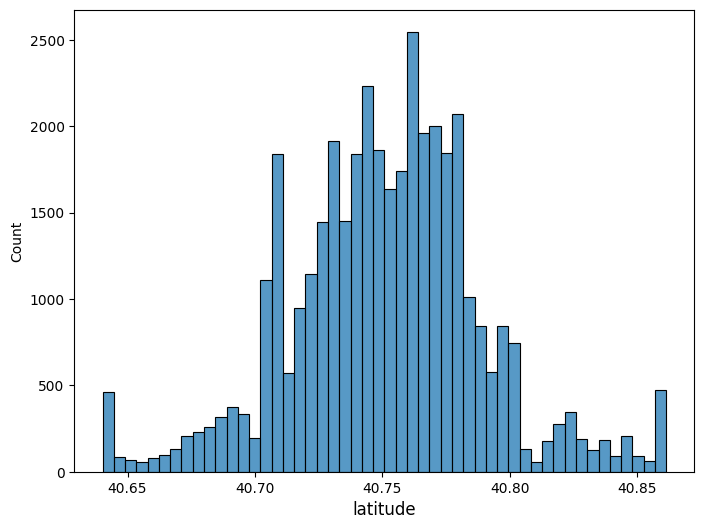

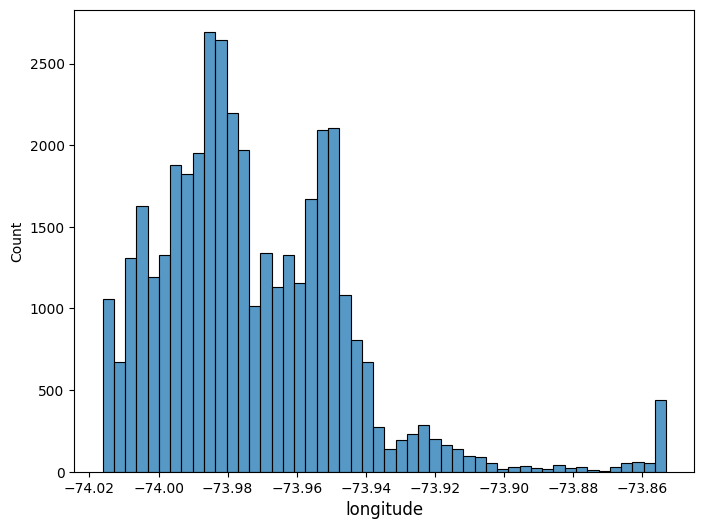

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute 1st and 99th percentiles
llimit = np.percentile(X_train.latitude.values, 1)
ulimit = np.percentile(X_train.latitude.values, 99)

# Clip values using .loc
X_train.loc[X_train['latitude'] < llimit, 'latitude'] = llimit
X_train.loc[X_train['latitude'] > ulimit, 'latitude'] = ulimit

# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(X_train.latitude.values, bins=50, kde=False)  # use histplot instead of distplot
plt.xlabel('latitude', fontsize=12)
plt.show()

# Compute 1st and 99th percentiles
llimit = np.percentile(X_train.longitude.values, 1)
ulimit = np.percentile(X_train.longitude.values, 99)

# Clip outliers using .loc
X_train.loc[X_train['longitude'] < llimit, 'longitude'] = llimit
X_train.loc[X_train['longitude'] > ulimit, 'longitude'] = ulimit

# Alternatively, a one-liner using clip:
# X_train['longitude'] = X_train['longitude'].clip(llimit, ulimit)

# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(X_train['longitude'].values, bins=50, kde=False)  # distplot is deprecated
plt.xlabel('longitude', fontsize=12)
plt.show()




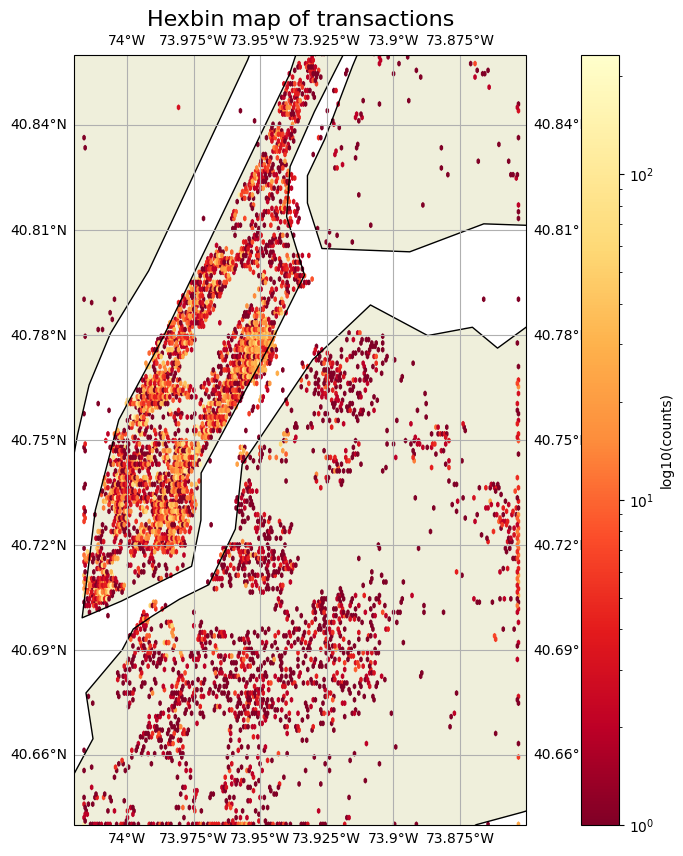

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


# make sure to change those based on ur data
west, south, east, north = -74.02, 40.64, -73.85, 40.86

fig = plt.figure(figsize=(14,10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())

# Add land, coastlines, and gridlines
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True)

# Plot points as a scatter or hexbin
hb = ax.hexbin(
    X_train['longitude'].values,
    X_train['latitude'].values,
    gridsize=200,
    bins='log',
    cmap='YlOrRd_r',
    transform=ccrs.PlateCarree()  # your data is in lat/lon
)

plt.colorbar(hb, ax=ax, label='log10(counts)')
plt.title('Hexbin map of transactions', fontsize=16)
plt.show()


Created/date_created

- are train and test from the same range data?
  

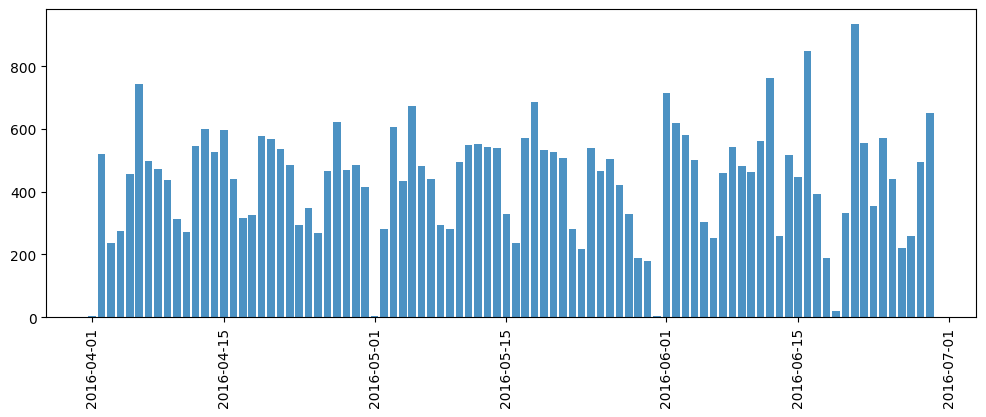

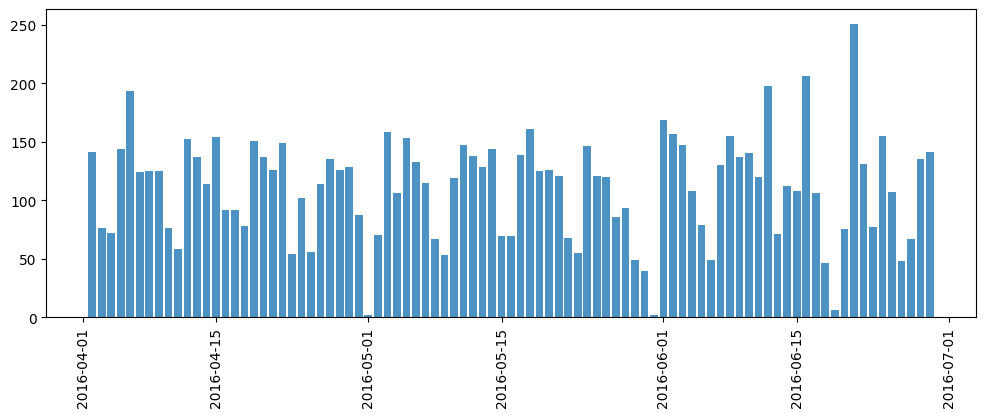

In [34]:
X_train["created"] = pd.to_datetime(X_train["created"])
X_train["date_created"] = X_train["created"].dt.date
cnt_srs = X_train['date_created'].value_counts()


plt.figure(figsize=(12,4))
ax = plt.subplot(111)
ax.bar(cnt_srs.index, cnt_srs.values, alpha=0.8)
ax.xaxis_date()
plt.xticks(rotation='vertical')
plt.show()


X_test["created"] = pd.to_datetime(X_test["created"])
X_test["date_created"] = X_test["created"].dt.date
cnt_srs = X_test['date_created'].value_counts()

plt.figure(figsize=(12,4))
ax = plt.subplot(111)
ax.bar(cnt_srs.index, cnt_srs.values, alpha=0.8)
ax.xaxis_date()
plt.xticks(rotation='vertical')
plt.show()

In [51]:
# convert the created column to datetime object so as to extract more features 
X_train["created"] = pd.to_datetime(X_train["created"])
X_test["created"] = pd.to_datetime(X_test["created"])

# Let us extract some features like year, month, day, hour from date columns #
X_train["created_year"] = X_train["created"].dt.year
X_test["created_year"] = X_test["created"].dt.year
X_train["created_month"] = X_train["created"].dt.month
X_test["created_month"] = X_test["created"].dt.month
X_train["created_day"] = X_train["created"].dt.day
X_test["created_day"] = X_test["created"].dt.day
X_train["created_hour"] = X_train["created"].dt.hour
X_test["created_hour"] = X_test["created"].dt.hour

Display Address:

Display_address that appear less than 2 times: 63.02%
Display_address that appear less than 10 times: 90.04%
Display_address that appear less than 50 times: 97.96%
Display_address that appear less than 100 times: 99.41%
Display_address that appear less than 500 times: 100.0%


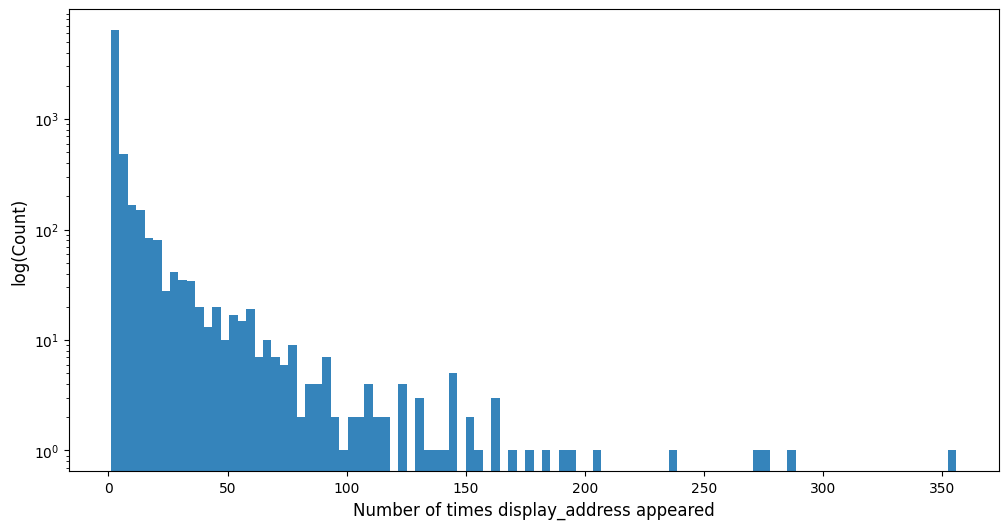

In [35]:
cnt_srs = X_train.groupby('display_address')['display_address'].count()

for i in [2, 10, 50, 100, 500]:
    print('Display_address that appear less than {} times: {}%'.format(i, round((cnt_srs < i).mean() * 100, 2)))

plt.figure(figsize=(12, 6))
plt.hist(cnt_srs.values, bins=100, log=True, alpha=0.9)
plt.xlabel('Number of times display_address appeared', fontsize=12)
plt.ylabel('log(Count)', fontsize=12)
plt.show()

features col

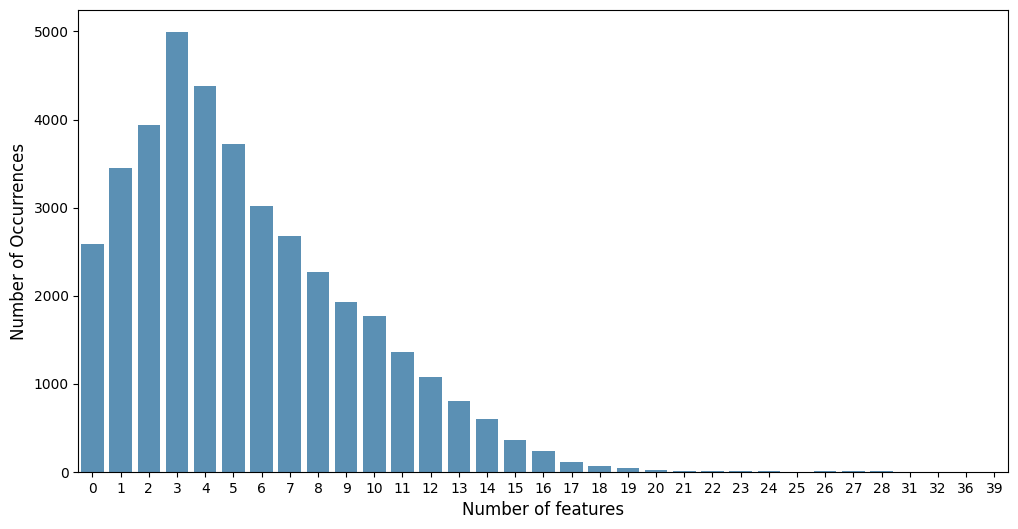

In [37]:
X_train["num_features"] = X_train["features"].apply(len)

cnt_srs = X_train['num_features'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=cnt_srs.index,
    y=cnt_srs.values,
    alpha=0.8
)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Number of features', fontsize=12)
plt.show()


**Word Clouds:**

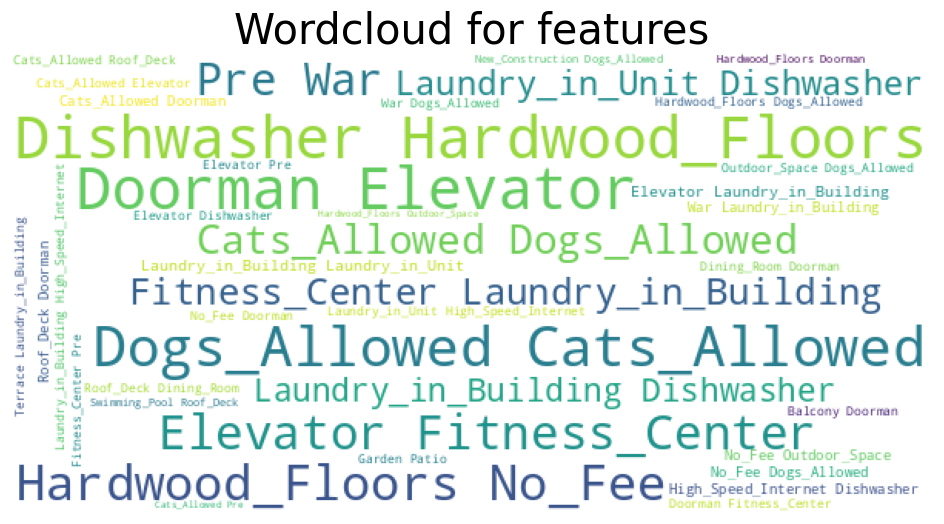

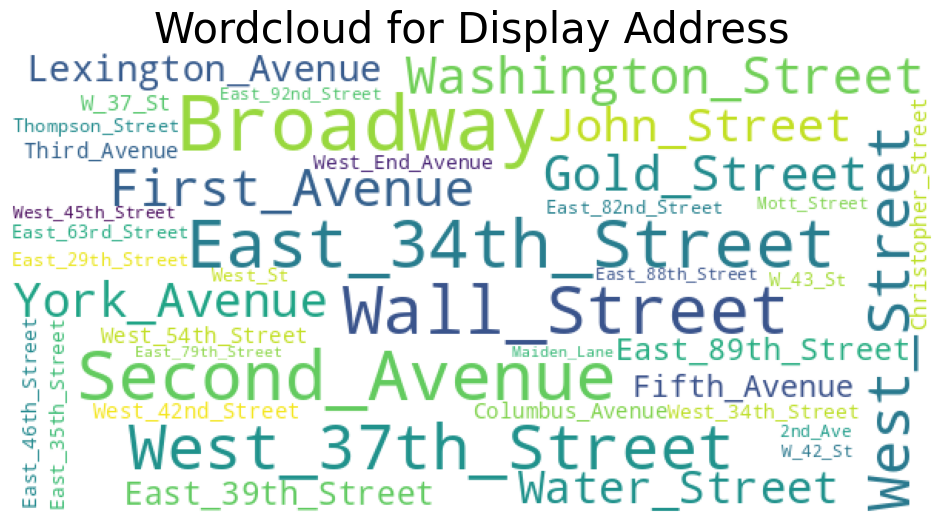

In [40]:
from wordcloud import WordCloud

text = ''
text_da = ''
text_desc = ''
for ind, row in X_train.iterrows():
    for feature in row['features']:
        text = " ".join([text, "_".join(feature.strip().split(" "))])
    text_da = " ".join([text_da,"_".join(row['display_address'].strip().split(" "))])
    #text_desc = " ".join([text_desc, row['description']])
text = text.strip()
text_da = text_da.strip()
text_desc = text_desc.strip()

plt.figure(figsize=(12,6))
wordcloud = WordCloud(background_color='white', width=600, height=300, max_font_size=50, max_words=40).generate(text)
wordcloud.recolor(random_state=0)
plt.imshow(wordcloud)
plt.title("Wordcloud for features", fontsize=30)
plt.axis("off")
plt.show()

# wordcloud for display address
plt.figure(figsize=(12,6))
wordcloud = WordCloud(background_color='white', width=600, height=300, max_font_size=50, max_words=40).generate(text_da)
wordcloud.recolor(random_state=0)
plt.imshow(wordcloud)
plt.title("Wordcloud for Display Address", fontsize=30)
plt.axis("off")
plt.show()

When using algorithms like Bag of Words, we lose the order of the words in the text, which means that the texts "i have no cows" and "no, i have cows" will appear identical after vectorization when, in fact, they have the opposite meaning. To avoid this problem, we can revisit our tokenization step and use N-grams (the sequence of N consecutive tokens) instead.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1,1))
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()

array([[1, 1, 1],
       [1, 1, 1]])

In [42]:
vect.vocabulary_ 

{'no': 2, 'have': 1, 'cows': 0}

In [45]:
vect = CountVectorizer(ngram_range=(1,2))
vect.fit_transform(['no i have cows', 'i have no cows']).toarray()


array([[1, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 1, 1, 1, 0]])

In [46]:
vect.vocabulary_ 

{'no': 4,
 'have': 1,
 'cows': 0,
 'no have': 6,
 'have cows': 2,
 'have no': 3,
 'no cows': 5}



Also note that one does not have to use only words. In some cases, it is possible to generate N-grams of characters. This approach would be able to account for similarity of related words or handle typos.


In [47]:


from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(3,3), analyzer='char_wb')

n1, n2, n3, n4 = vect.fit_transform(['andersen', 'petersen', 'petrov', 'smith']).toarray()

euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)



(2.8284271247461903, 3.1622776601683795, 3.3166247903554)



Adding onto the Bag of Words idea: words that are rarely found in the corpus (in all the documents of this dataset) but are present in this particular document might be more important. Then it makes sense to increase the weight of more domain-specific words to separate them out from common words. This approach is called TF-IDF (term frequency-inverse document frequency), which cannot be written in a few lines.


Analogs of Bag of Words can be found outside of text problems e.g. bag of sites in the Catch Me If You Can competition, bag of apps, bag of events,

Using these algorithms, it is possible to obtain a working solution for a simple problem, which can serve as a baseline. However, for those who do not like the classics, there are new approaches. The most popular method in the new wave is Word2Vec, but there are a few alternatives as well (GloVe, Fasttext, etc.).

In [49]:
# count of words present in description column #


train_df = X_train.copy()
test_df = X_test.copy()

train_df["num_description_words"] = X_train["description"].apply(lambda x: len(x.split(" ")))
test_df["num_description_words"] = X_test["description"].apply(lambda x: len(x.split(" ")))


In [50]:
train_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,date_created,num_features,num_description_words
73175,1.0,2,750f265a50473ce6c515bfded25e24f5,2016-05-27 03:13:27,BROWNSTONE<br/><br/><br/><br/>This is a Gut Re...,E 55 St.,"[Cats Allowed, Dogs Allowed, Pre-War, Laundry ...",40.7572,7074626,-73.9648,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7074626_0d023cf0...,3000,340 E 55 St.,2016-05-27,5,62
98972,1.0,3,92fac62c9f219b584d40065698c48889,2016-04-05 06:24:11,Location Location Location!!~~~>Stunning West ...,Hudson St.,"[Laundry in Unit, Dishwasher, Hardwood Floors,...",40.7347,6826465,-74.0063,a0b48b00a6c51ff9f0c10dcd2a8592a6,[https://photos.renthop.com/2/6826465_0439112b...,6600,535 Hudson St.,2016-04-05,5,40
38546,1.0,2,0,2016-06-10 12:25:46,Dream Chelsea location!! W 21st/8th Ave***RENO...,W 21ST AND 8TH AVE,"[Cats Allowed, Dogs Allowed]",40.7440,7137830,-73.9994,edd073f8dea85637f8b7d589faa7902b,[https://photos.renthop.com/2/7137830_25aa8da5...,2695,W 21ST AND 8TH AVE,2016-06-10,2,11
121647,1.0,1,72af1c8a4c9f9235dd8e14ff41843d82,2016-04-19 05:24:02,"This large 1 bedroom apartment with Balcony, N...",E 13 St.,"[Laundry in Unit, Dishwasher, Hardwood Floors,...",40.7299,6895084,-73.9819,4f9b376a972b863bbfbdcdc8d717fa4e,[https://photos.renthop.com/2/6895084_bf9d1847...,2895,432 E 13 St.,2016-04-19,6,94
11939,1.0,2,b1ff13eed93ba353d5cc103088276c6e,2016-06-09 03:45:31,Really Large 2BR in the Upper East Side really...,E 61 Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7617,7130431,-73.9626,1dc73580d149c88bd976bba1c4a02b12,[https://photos.renthop.com/2/7130431_56dd5e26...,2675,311 E 61 Street,2016-06-09,3,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41268,1.0,0,57ef86c28a8ae482dc3a3c3af28e8e48,2016-06-08 04:15:13,Incredible building with endless amenities inc...,10 Ave.,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7593,7125105,-73.9962,2d94da7b0535231e6675cbf52a7e7453,[https://photos.renthop.com/2/7125105_7812ae8c...,2595,561 10 Ave.,2016-06-08,10,127
93701,1.0,2,0,2016-04-04 03:33:20,This gorgeous 2 bed features a bright beautifu...,West 109th Street,"[prewar, Dogs Allowed, Cats Allowed, LOWRISE, ...",40.8034,6821499,-73.9661,b6ea5498ce80f151f5334f675fb10ddc,[https://photos.renthop.com/2/6821499_ddc961fb...,3200,245 West 109th Street,2016-04-04,7,226
14564,1.0,2,6bdbf365ac2efe5dad1964d43f2f8715,2016-06-16 06:10:36,First floor apartment in Ditmas park Renovated...,E 16th St.,[Hardwood Floors],40.6402,7170531,-73.9614,9d3a8dd3eeaf09f0214de38b02c9eb60,[https://photos.renthop.com/2/7170531_abb66bfd...,1950,613 E 16th St.,2016-06-16,1,84
29790,1.0,2,0,2016-06-07 05:24:27,Stunning Gut Renovated Brownstone On Franklin ...,Franklin Ave,"[Laundry in Building, Dishwasher, Hardwood Flo...",40.6852,7120597,-73.9563,9ba3641676cc717a8b65d59dac8545fb,[https://photos.renthop.com/2/7120597_1430c7be...,2950,405 Franklin Ave,2016-06-07,4,70


# Resampling strategies for imbalanced datasets

The simplest implementation of over-sampling is to duplicate random records from the minority class, which can cause overfitting. In under-sampling, the simplest technique involves removing random records from the majority class, which can cause loss of information.


#### Random under-sampling


In [140]:

# Class count
count_class_0 = (y_train == 0).sum()
count_class_1 = (y_train == 1).sum()

print("Class 0 count:", count_class_0)
print("Class 1 count:", count_class_1)

# Divide by class
df_class_0 = X_train[y_train == 0]
df_class_1 = X_train[y_train == 1]




Class 0 count: 458814
Class 1 count: 17355


Random under-sampling:
target
0    17355
1    17355
Name: count, dtype: int64


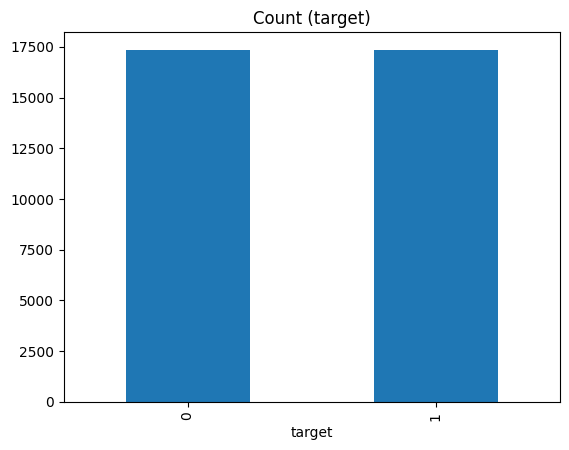

In [141]:
# Random under-sampling
df_class_0_under = df_class_0.sample(n=count_class_1, random_state=42)  # sample from class 0
X_under = pd.concat([df_class_0_under, df_class_1], axis=0)
y_under = pd.concat([y_train[y_train == 0].loc[df_class_0_under.index],
                     y_train[y_train == 1]], axis=0)

print('Random under-sampling:')
print(y_under.value_counts())

# Plot
y_under.value_counts().plot(kind='bar', title='Count (target)');


# Random over-sampling


Random over-sampling:
target
0    458814
1    458814
Name: count, dtype: int64


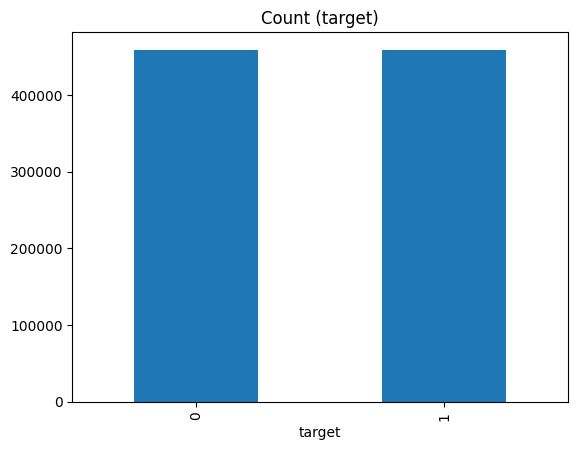

In [142]:
from sklearn.utils import resample

# Random over-sampling
df_class_1_over = df_class_1.sample(n=count_class_0, replace=True, random_state=42)  # sample with replacement
X_over = pd.concat([df_class_0, df_class_1_over], axis=0)
y_over = pd.concat([y_train[y_train == 0],
                    y_train[y_train == 1].loc[df_class_1_over.index]], axis=0)

print('Random over-sampling:')
print(y_over.value_counts())

# Plot
y_over.value_counts().plot(kind='bar', title='Count (target)');


# Python imbalanced-learn module
A number of more sophisticated resapling techniques have been proposed in the scientific literature.

For example, we can cluster the records of the majority class, and do the under-sampling by removing records from each cluster, thus seeking to preserve information. In over-sampling, instead of creating exact copies of the minority class records, we can introduce small variations into those copies, creating more diverse synthetic samples.

Let's apply some of these resampling techniques, using the Python library imbalanced-learn. It is compatible with scikit-learn and is part of scikit-learn-contrib projects.

In [143]:
import imblearn



For ease of visualization, let's create a small unbalanced sample dataset using the make_classification method:


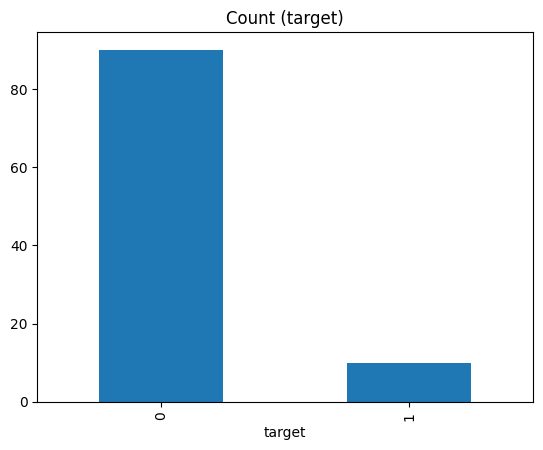

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate imbalanced dataset
X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    n_classes=2,
    weights=[0.9, 0.1],
    flip_y=0,
    class_sep=1.5,
    random_state=10
)

# Create DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

# Plot target counts
df['target'].value_counts().plot(kind='bar', title='Count (target)')
plt.show()


2-dimensional plot function, plot_2d_space, to see the data distribution:

In [146]:
def plot_2d_space(X, y, label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()



Because the dataset has many dimensions (features) and our graphs will be 2D, we will reduce the size of the dataset using Principal Component Analysis (PCA):


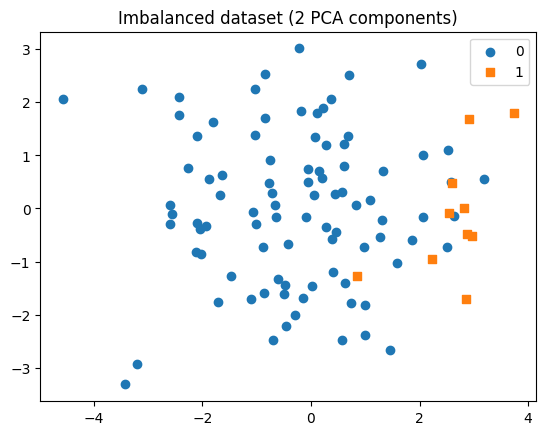

In [147]:


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(X)

plot_2d_space(X, y, 'Imbalanced dataset (2 PCA components)')




Random under-sampling and over-sampling with imbalanced-learn

<mark>Note here X is X_pca</mark>

Removed indexes: [1, 2, 3, 5, 6, 7, 10, 11, 12, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 68, 69, 72, 73, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


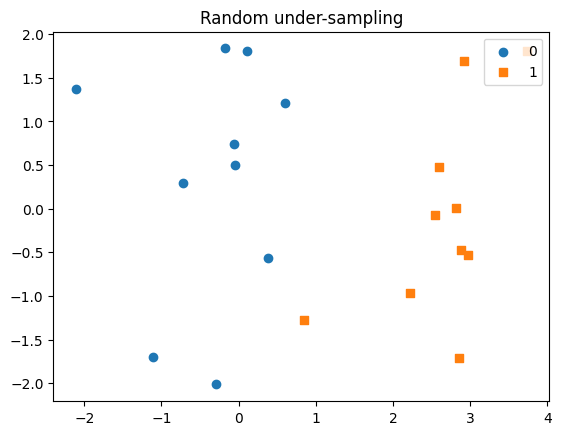

In [150]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize the under-sampler
rus = RandomUnderSampler(random_state=42)

# Fit and resample
X_rus, y_rus = rus.fit_resample(X, y)

# Get removed indexes (optional)
removed_indices = list(set(range(len(X))) - set(rus.sample_indices_))
print('Removed indexes:', removed_indices)

# Plot the 2D space
plot_2d_space(X_rus, y_rus, 'Random under-sampling')


80 new randomly picked points


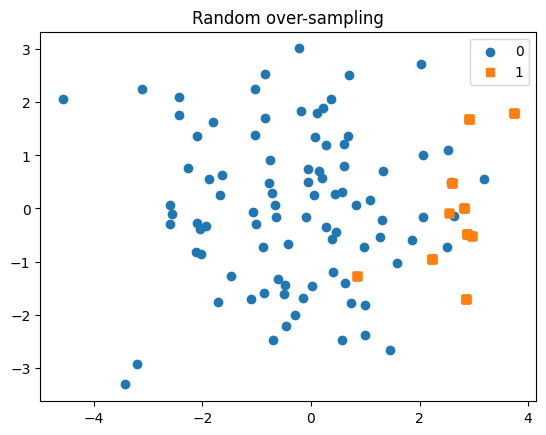

In [151]:
from imblearn.over_sampling import RandomOverSampler

# Create the oversampler
ros = RandomOverSampler(random_state=42)

# Fit and resample
X_ros, y_ros = ros.fit_resample(X, y)  # X can be PCA or original features

# How many new points were added
print(X_ros.shape[0] - X.shape[0], 'new randomly picked points')

# Plot in 2D
plot_2d_space(X_ros, y_ros, 'Random over-sampling')


# Under-sampling: Tomek links

Tomek links are pairs of very close instances, but of opposite classes. Removing the instances of the majority class of each pair increases the space between the two classes, facilitating the classification process.



In the code below, we'll use ratio='majority' to resample the majority class.


Removed 4 points


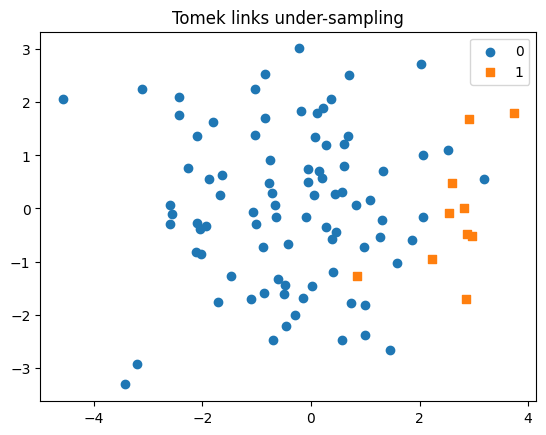

In [152]:
from imblearn.under_sampling import TomekLinks

# Create TomekLinks object
tl = TomekLinks()

# Fit and resample
X_tl, y_tl = tl.fit_resample(X, y)  # X can be PCA or original features

# How many points were removed
print(f'Removed {X.shape[0] - X_tl.shape[0]} points')

# Plot in 2D
plot_2d_space(X_tl, y_tl, 'Tomek links under-sampling')


# Under-sampling: Cluster Centroids
This technique performs under-sampling by generating centroids based on clustering methods. The data will be previously grouped by similarity, in order to preserve information.

In this example we will pass the {0: 10} dict for the parameter ratio, to preserve 10 elements from the majority class (0), and all minority class (1) .

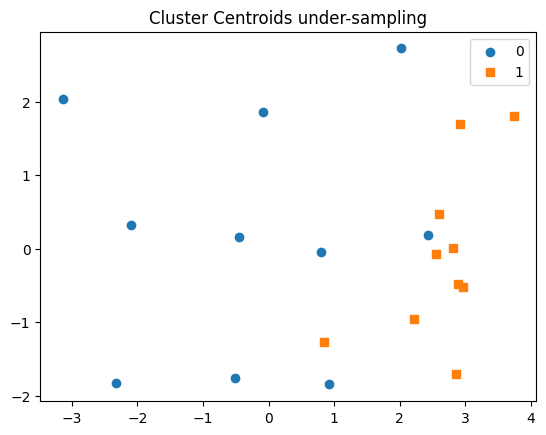

In [154]:
from imblearn.under_sampling import ClusterCentroids

# Create ClusterCentroids object
# 'sampling_strategy' defines the number of samples per class after resampling
cc = ClusterCentroids(sampling_strategy={0: 10})  # reduce class 0 to 10 samples

# Fit and resample
X_cc, y_cc = cc.fit_resample(X, y)

# Plot
plot_2d_space(X_cc, y_cc, 'Cluster Centroids under-sampling')


# Over-sampling: SMOTE
SMOTE (Synthetic Minority Oversampling TEchnique) consists of synthesizing elements for the minority class, based on those that already exist. It works randomly picingk a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.



We'll use ratio='minority' to resample the minority class.


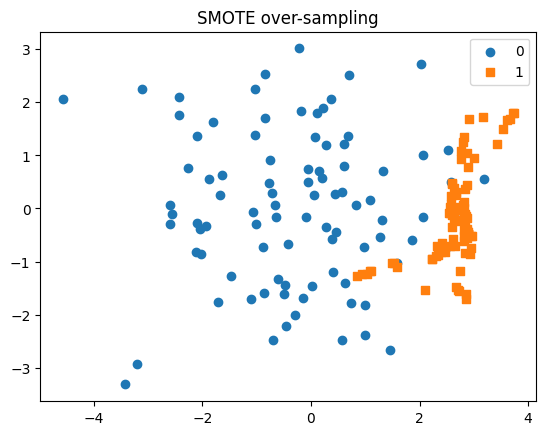

In [155]:
from imblearn.over_sampling import SMOTE

# SMOTE object, now use 'sampling_strategy' instead of 'ratio'
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Fit and resample
X_sm, y_sm = smote.fit_resample(X, y)

# Plot the new balanced dataset
plot_2d_space(X_sm, y_sm, 'SMOTE over-sampling')

# Over-sampling followed by under-sampling

Now, we will do a combination of over-sampling and under-sampling, using the SMOTE and Tomek links techniques:

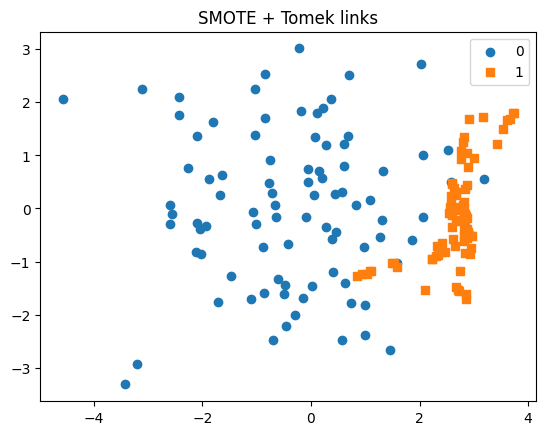

In [157]:
from imblearn.combine import SMOTETomek

# SMOTE + Tomek links, use sampling_strategy instead of ratio
smt = SMOTETomek(sampling_strategy='auto', random_state=42)

# Fit and resample
X_smt, y_smt = smt.fit_resample(X, y)

# Plot the new dataset
plot_2d_space(X_smt, y_smt, 'SMOTE + Tomek links')


In [29]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)




Log transform


In [13]:
# # Plot log transform results
# fig=plt.figure(figsize=(12,20))
# for i, col in enumerate(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']):
#     plt.subplot(6,2,2*i+1)
#     sns.histplot(X_train[col], binwidth=100)
#     plt.ylim([0,200])
#     plt.title(f'{col} (original)')
    
#     plt.subplot(6,2,2*i+2)
#     sns.histplot(np.log(1+X_train[col]), color='C1')
#     plt.ylim([0,200])
#     plt.title(f'{col} (log-transform)')
    
# fig.tight_layout()
# plt.show()

In [ ]:
# # Apply log transform
# for col in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Expenditure']:
#     X_train[col]=np.log(1+X_train[col])
#     X_test[col]=np.log(1+X_test[col])



Encoding and scaling



We will use column transformers to be more professional. It's also good practice.


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder


numerical_cols = [cname for cname in X_train.columns if X_train[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X_train.columns if X_train[cname].dtype == "object"]

# Scale numerical data to have mean=0 and variance=1
numerical_transformer = Pipeline([('scaler', StandardScaler())])

# One-hot encode categorical data
categorical_transformer = Pipeline([('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))])

# Combine preprocessing
ct = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)],
        remainder='passthrough')

# Apply preprocessing
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Print new shape
print('Training set shape:', X_train.shape)

Training set shape: (6954, 36)


# Imbalanced Data

<Axes: title={'center': 'Count (target)'}, xlabel='target'>

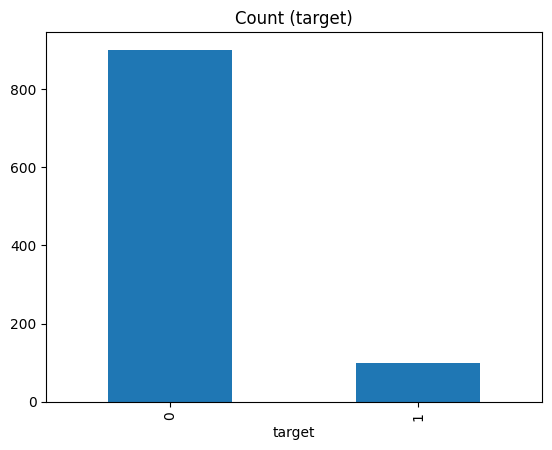

In [14]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_classes=2, class_sep=1.5, weights=[0.9, 0.1],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=1000, random_state=10
)

df = pd.DataFrame(X)
df['target'] = y
df.target.value_counts().plot(kind='bar', title='Count (target)')


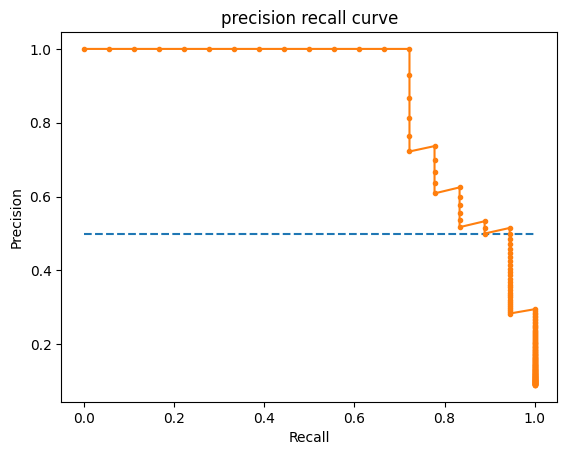

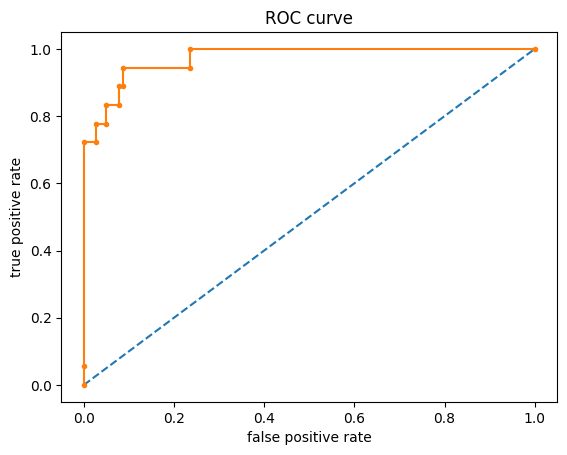

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve


def logistic(X,y):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=1)
    lr=LogisticRegression()
    lr.fit(X_train,y_train)
    prob=lr.predict_proba(X_test)
    return (prob[:,1],y_test)

probs,y_test=logistic(X,y)

def plot_pre_curve(y_test,probs):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    plt.plot([0, 1], [0.5, 0.5], linestyle='--')
    # plot the precision-recall curve for the model
    plt.plot(recall, precision, marker='.')
    plt.title("precision recall curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the plot
    plt.show()
    
def plot_roc(y_test,prob):
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    # plot no skill
    plt.plot([0, 1], [0, 1], linestyle='--')
    # plot the roc curve for the model
    plt.plot(fpr, tpr, marker='.')
    plt.title("ROC curve")
    plt.xlabel('false positive rate')
    plt.ylabel('true positive rate')
    # show the plot
    plt.show()



plot_pre_curve(y_test,probs)

plot_roc(y_test,probs)

T-SNE took 0.24 s
PCA took 0.0033 s
Truncated SVD took 0.0024 s


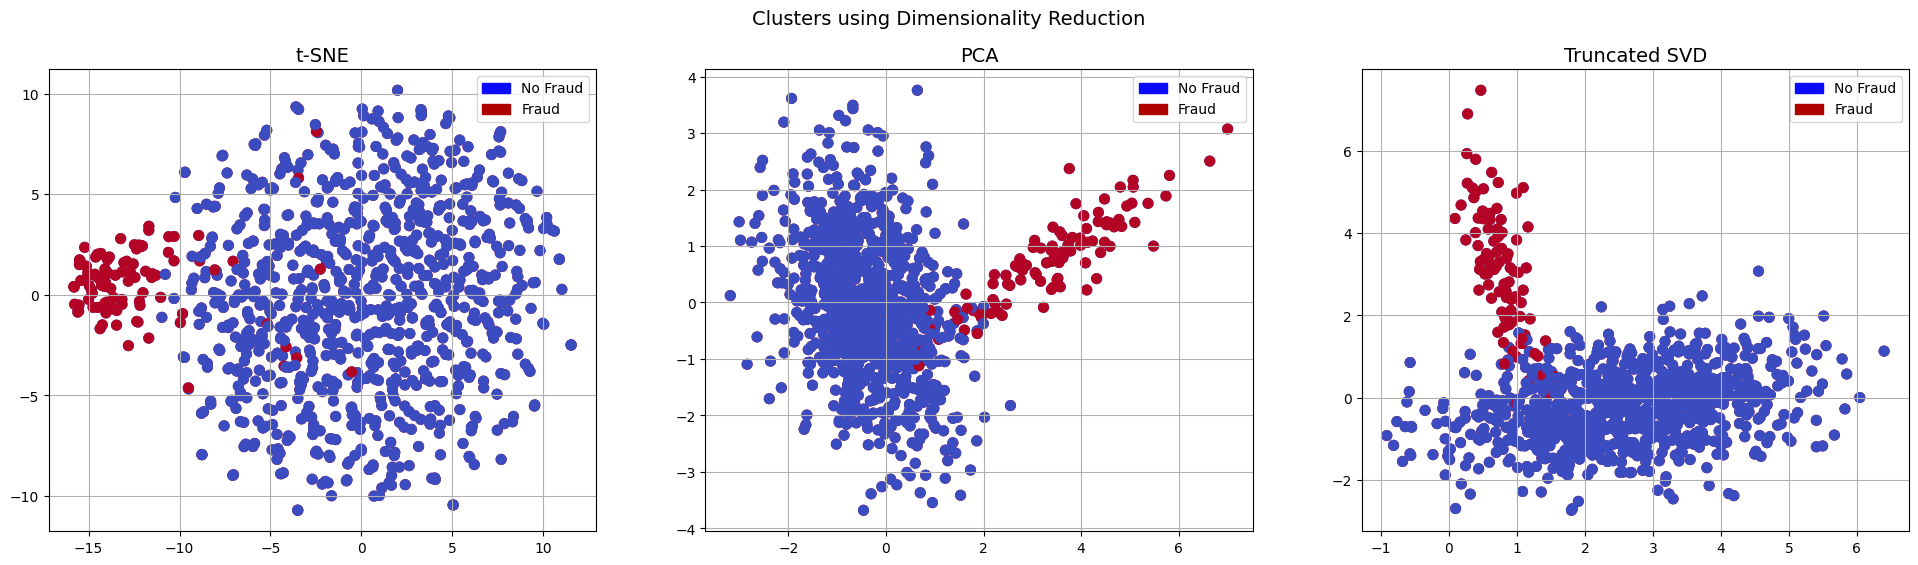

In [25]:
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches


def plot_2d_space(X_train, y_train,X=X,y=y ,label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    
    fig,(ax1,ax2)=plt.subplots(1,2, figsize=(8,4))
   
    for l, c, m in zip(np.unique(y), colors, markers):
        ax1.scatter(
            X_train[y_train==l, 0],
            X_train[y_train==l, 1],
            c=c, label=l, marker=m
        )
    for l, c, m in zip(np.unique(y), colors, markers):
        ax2.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
   
    ax1.set_title(label)
    ax2.set_title('original data')
    plt.legend(loc='upper right')
    plt.show()


# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))


f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()



Random under-sampling with imbalanced-learn


In [27]:
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# initialize undersampler
rus = RandomUnderSampler(random_state=42)

# fit and resample
X_res, y_res = rus.fit_resample(X, y)

# indices of kept samples in the original dataset
kept_indices = rus.sample_indices_

# optional: indices of dropped samples
all_indices = np.arange(len(X))
dropped_indices = np.setdiff1d(all_indices, kept_indices)

print("Number of dropped indices:", len(dropped_indices))


Number of dropped indices: 800


- Let's try fit and predict on this data and observe the outcome.



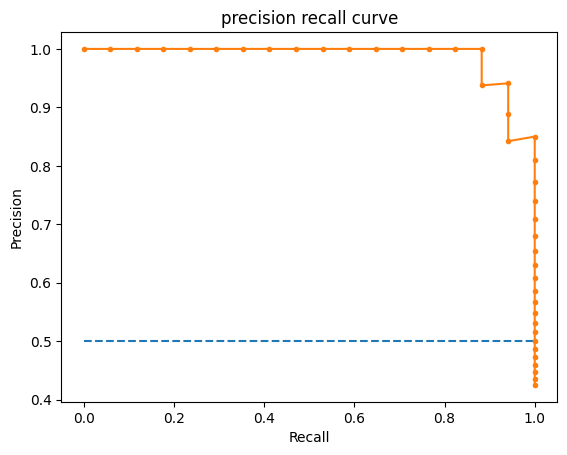

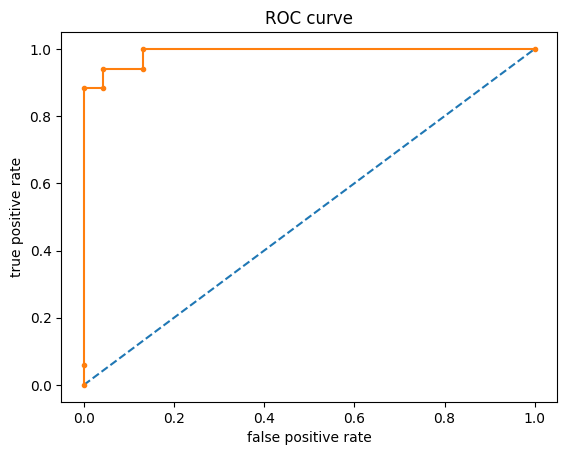

In [29]:
probs,y_test=logistic(X_res,y_res)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)


Random over-sampling with imbalanced-learn


The new data contains 1800 rows.
Class distribution after oversampling: {0: 900, 1: 900}


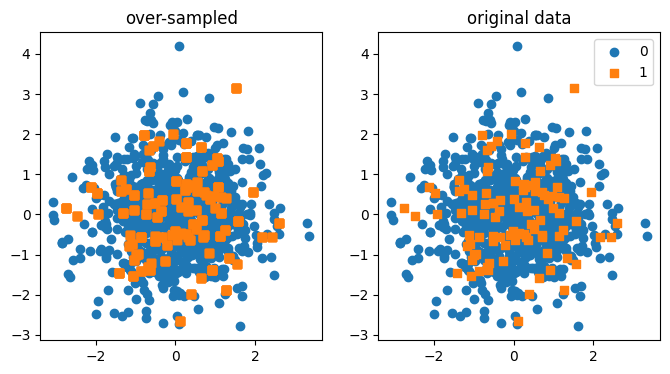

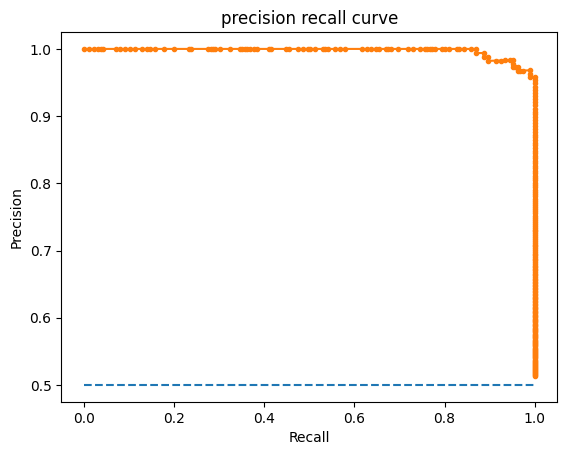

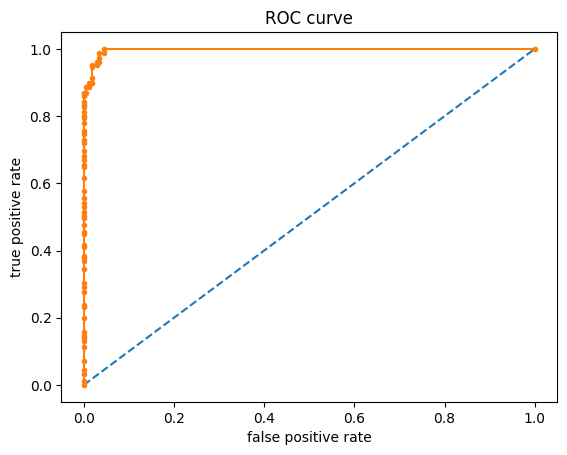

In [32]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Initialize oversampler
ros = RandomOverSampler(random_state=42)

# Resample
X_ran, y_ran = ros.fit_resample(X, y)

print(f'The new data contains {X_ran.shape[0]} rows.')

# Optional: check class distribution
unique, counts = np.unique(y_ran, return_counts=True)
print("Class distribution after oversampling:", dict(zip(unique, counts)))

# Plot 2D space (assumes you have plot_2d_space defined)
plot_2d_space(X_ran, y_ran, X, y, 'over-sampled')
probs,y_test=logistic(X_ran,y_ran)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)



Under-sampling: Tomek links

Tomek links are pairs of very close instances, but of opposite classes. Removing the instances of the majority class of each pair increases the space between the two classes, facilitating the classification process.

Number of dropped samples: 4


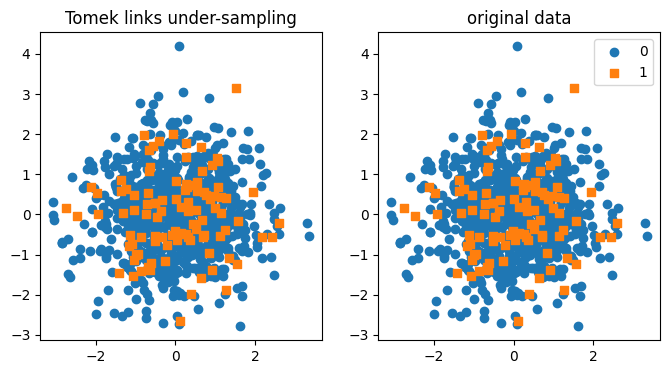

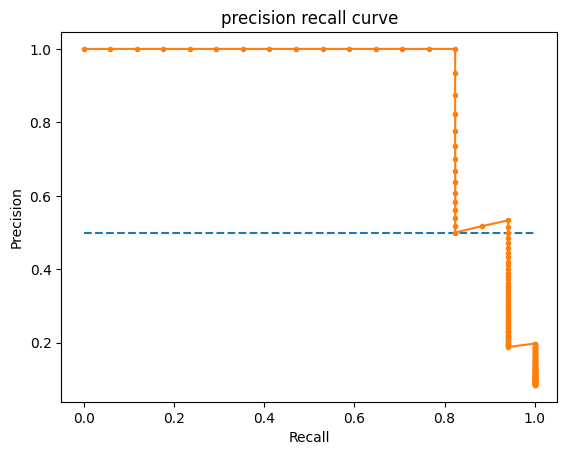

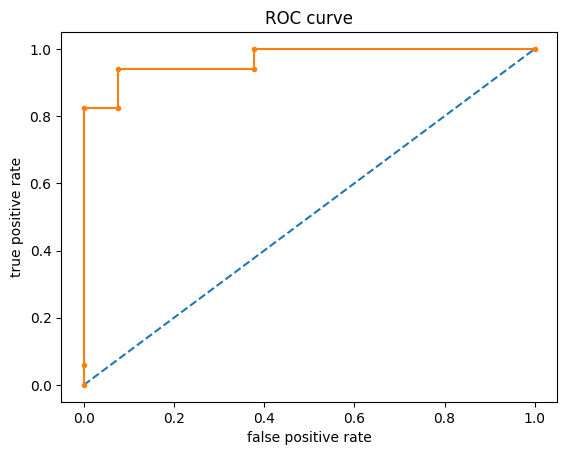

In [33]:
from imblearn.under_sampling import TomekLinks
import numpy as np

# Initialize sampler
tl = TomekLinks(sampling_strategy='majority')  # 'ratio' is old, now use sampling_strategy

# Fit and resample
X_tl, y_tl = tl.fit_resample(X, y)

# Indices of samples kept
kept_indices = tl.sample_indices_

# Optional: indices of removed samples
all_indices = np.arange(len(X))
dropped_indices = np.setdiff1d(all_indices, kept_indices)
print("Number of dropped samples:", len(dropped_indices))

# Plot 2D space (assumes plot_2d_space is defined)
plot_2d_space(X_tl, y_tl, X, y, 'Tomek links under-sampling')

probs,y_test=logistic(X_tl,y_tl)
plot_pre_curve(y_test,probs)
plot_roc(y_test,probs)


Over-sampling: SMOTE

SMOTE (Synthetic Minority Oversampling TEchnique) consists of synthesizing elements for the minority class, based on those that already exist. It works randomly picingk a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.


<mark>Very nice kernel indeed. However, oversampling (SMOTE) should only be applied after splitting the data into folds imo. Applying SMOTE before splitting leaks data (the oversampled portion) to the train sets and therefore, overfitting the validation sets, hence the very high AUC as being shown.</mark>


<mark>Nice kernel! For oversampling, I've found that SMOTE combined with edited nearest neighbors (ENN) tends to perform slightly better than SMOTE, but takes longer to run. It's definitely worth looking into. Here's the code for that: https://imbalanced-learn.readthedocs.io/en/stable/generated/imblearn.combine.SMOTEENN.html</mark>

Class distribution after SMOTE: {0: 900, 1: 900}


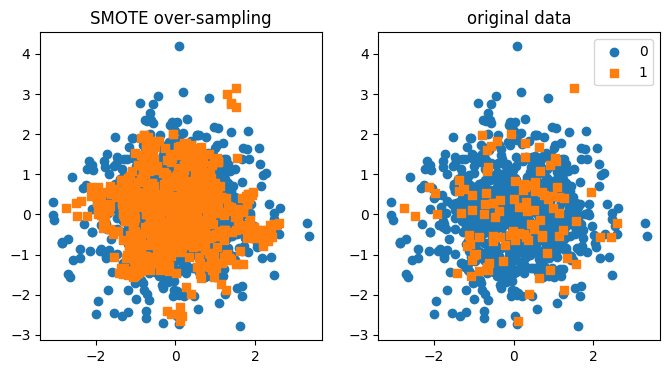

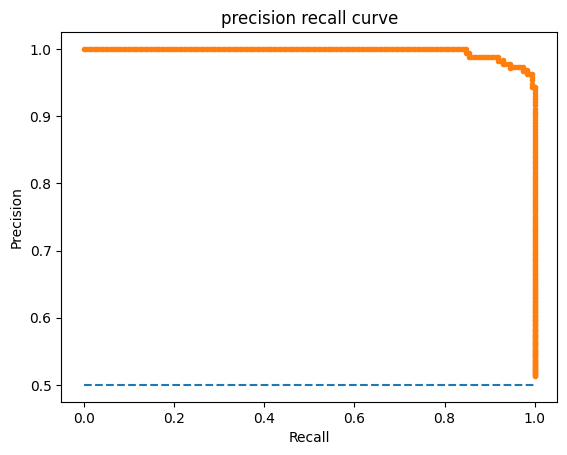

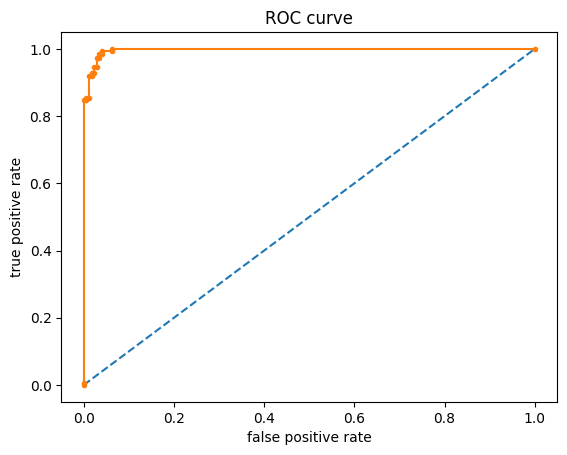

In [34]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Fit and resample
X_sm, y_sm = smote.fit_resample(X, y)

# Optional: check class distribution after SMOTE
unique, counts = np.unique(y_sm, return_counts=True)
print("Class distribution after SMOTE:", dict(zip(unique, counts)))

# Plot 2D space (assumes plot_2d_space is defined)
plot_2d_space(X_sm, y_sm, X, y, 'SMOTE over-sampling')


probs,y_test=logistic(X_sm,y_sm)
plot_pre_curve(y_test,probs)

plot_roc(y_test,probs)

# Fill missing values

In [ ]:
X_train[cat_cols] = X_train[cat_cols].fillna('Unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('Unknown')

This need special treatment

In [ ]:
# print(X_train['attitude_worried_shutdown'].value_counts())
# print(X_train['current_problem_cash_flow'].value_counts())

# New Features

# V1
showed good improvment

In [ ]:
from sklearn.model_selection import KFold
import numpy as np


TARGET = 'has_condition'
orig = X_train.copy()
orig[TARGET] = y_train
BASE = X_train.columns.tolist()
def kfold_target_encoding(X, y, col, n_splits=5):
    X_new = X.copy()
    global_mean = y.mean()
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_new[f"te_{col}"] = np.nan
    
    for train_idx, val_idx in kf.split(X):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]

        mean_map = X_tr.groupby(col).apply(lambda x: y_tr.loc[x.index].mean())

        X_new.iloc[val_idx, X_new.columns.get_loc(f"te_{col}")] = X_val[col].map(mean_map)

    X_new[f"te_{col}"] = X_new[f"te_{col}"].fillna(global_mean)
    return X_new[f"te_{col}"]


for col in BASE:
    X_train[f"te_{col}"] = kfold_target_encoding(X_train, y_train, col)



global_mean = y_train.mean()

for col in BASE:
    mean_map = X_train.groupby(col)[f"te_{col}"].mean()
    X_test[f"te_{col}"] = X_test[col].map(mean_map).fillna(global_mean)


for col in BASE:
    count_map = X_train[col].value_counts()
    X_train[f"count_{col}"] = X_train[col].map(count_map)
    X_test[f"count_{col}"]  = X_test[col].map(count_map).fillna(0)


ORIG = [f"te_{col}" for col in BASE] + [f"count_{col}" for col in BASE]
FEATURES = BASE + ORIG




In [ ]:
new_features = list(set(X_train.columns) - set(X_train_original.columns))
print("New features added:")
print(new_features)
print(X_train[new_features].dtypes)


New features added:
['lifestyle_risk', 'count_ldl_chol', 'bp_category', 'te_pulse_rate', 'te_ethnic_group', 'count_income_class', 'te_has_cardiovascular', 'bp_bmi', 'age_group', 'count_daily_screen_hrs', 'count_whr', 'count_hdl_chol', 'count_nutrition_index', 'count_ethnic_group', 'te_tobacco_use', 'bmi_category', 'hypertension_stage', 'te_has_hypertension', 'count_family_diabetes', 'count_body_mass_idx', 'count_bp_systolic', 'age_chol', 'te_whr', 'te_bp_diastolic', 'hypertension_flag', 'te_weekly_alcohol', 'count_tobacco_use', 'count_bp_diastolic', 'te_total_chol', 'count_has_hypertension', 'lifestyle_level', 'te_family_diabetes', 'bp_ratio', 'te_daily_screen_hrs', 'te_daily_sleep_hrs', 'bmi_chol', 'count_weekly_exercise_min', 'count_pulse_rate', 'te_bp_systolic', 'count_daily_sleep_hrs', 'age_bmi', 'age_category', 'te_years_old', 'te_body_mass_idx', 'bmi_squared', 'te_weekly_exercise_min', 'medical_risk', 'count_work_status', 'medical_history_count', 'count_weekly_alcohol', 'age_squa

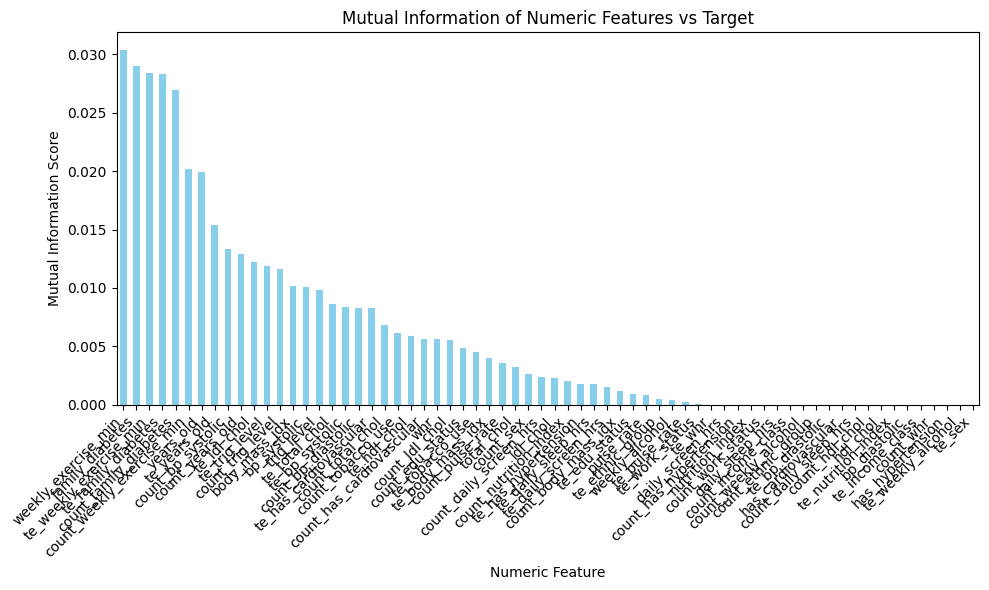

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Numeric features
num_cols = X_train.select_dtypes(include='number').columns
X_num = X_train[num_cols].copy()

# Simple imputer: fill NaN with median (robust)
imputer = SimpleImputer(strategy='median')
X_num_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=num_cols)

from sklearn.feature_selection import mutual_info_classif


mi_scores = mutual_info_classif(X_num_imputed, y_train, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
mi_series.plot(kind='bar', color='skyblue')
plt.title("Mutual Information of Numeric Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



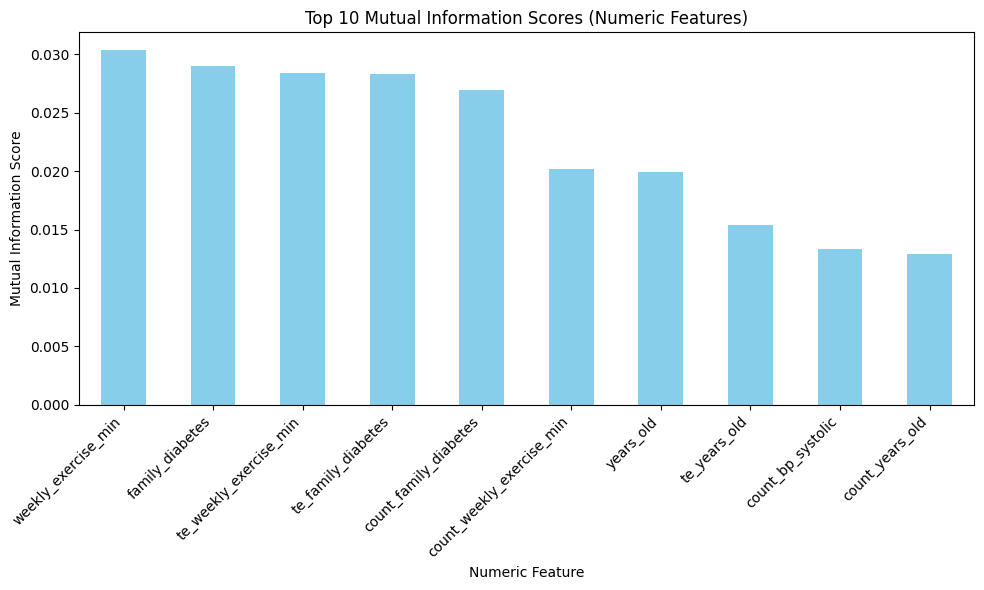

In [ ]:
# Take top 10 features
top10_mi = mi_series.head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top10_mi.plot(kind='bar', color='skyblue')
plt.title("Top 10 Mutual Information Scores (Numeric Features)")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


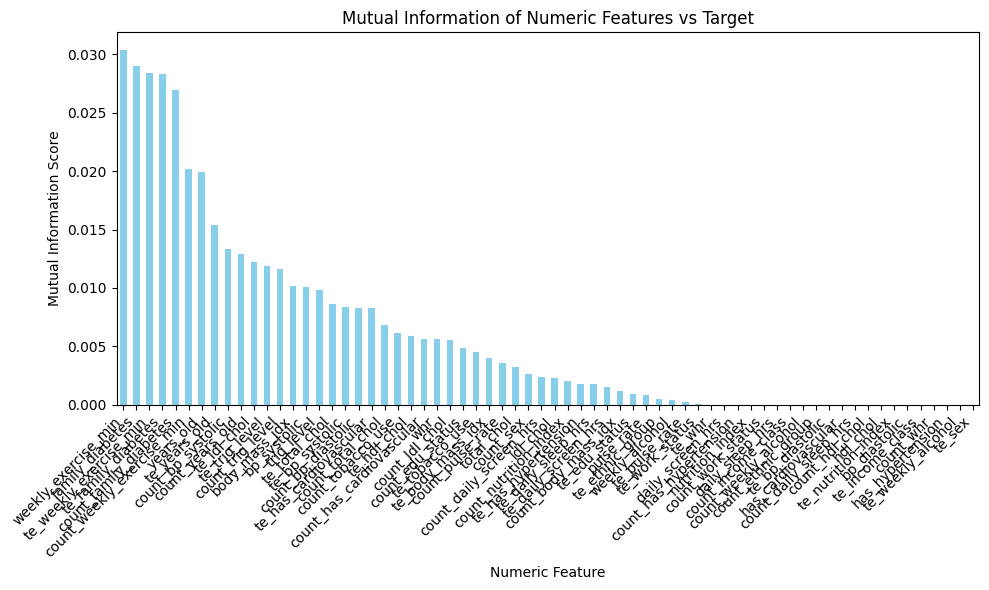

Columns with MI < 0.005: ['count_edu_status', 'te_tobacco_use', 'te_body_mass_idx', 'count_pulse_rate', 'total_chol', 'count_sex', 'count_daily_screen_hrs', 'ldl_chol', 'count_nutrition_index', 'te_has_hypertension', 'te_daily_sleep_hrs', 'te_daily_screen_hrs', 'count_body_mass_idx', 'te_edu_status', 'pulse_rate', 'te_ethnic_group', 'weekly_alcohol', 'te_pulse_rate', 'te_work_status', 'te_whr', 'daily_screen_hrs', 'count_has_hypertension', 'nutrition_index', 'count_work_status', 'daily_sleep_hrs', 'count_income_class', 'count_weekly_alcohol', 'count_ethnic_group', 'te_bp_diastolic', 'has_cardiovascular', 'count_daily_sleep_hrs', 'count_hdl_chol', 'hdl_chol', 'te_nutrition_index', 'bp_diastolic', 'te_income_class', 'count_whr', 'has_hypertension', 'te_weekly_alcohol', 'te_sex']


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# ---------------------------
# Numeric features
# ---------------------------
num_cols = X_train.select_dtypes(include='number').columns
X_num = X_train[num_cols].copy()

# Fill NaN with median
imputer = SimpleImputer(strategy='median')
X_num_imputed = pd.DataFrame(imputer.fit_transform(X_num), columns=num_cols)

# ---------------------------
# Compute mutual information
# ---------------------------
# Ensure target is numeric
if y_train.dtype == 'object':
    y_encoded, _ = pd.factorize(y_train)
else:
    y_encoded = y_train.values

mi_scores = mutual_info_classif(X_num_imputed, y_encoded, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)

# ---------------------------
# Plot MI
# ---------------------------
plt.figure(figsize=(10,6))
mi_series.plot(kind='bar', color='skyblue')
plt.title("Mutual Information of Numeric Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Numeric Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------
# Columns with MI < 0.005
# ---------------------------
low_mi_cols = mi_series[mi_series < 0.005].index.tolist()
print("Columns with MI < 0.005:", low_mi_cols)


Index(['sex', 'ethnic_group', 'edu_status', 'income_class', 'tobacco_use',
       'work_status'],
      dtype='object')


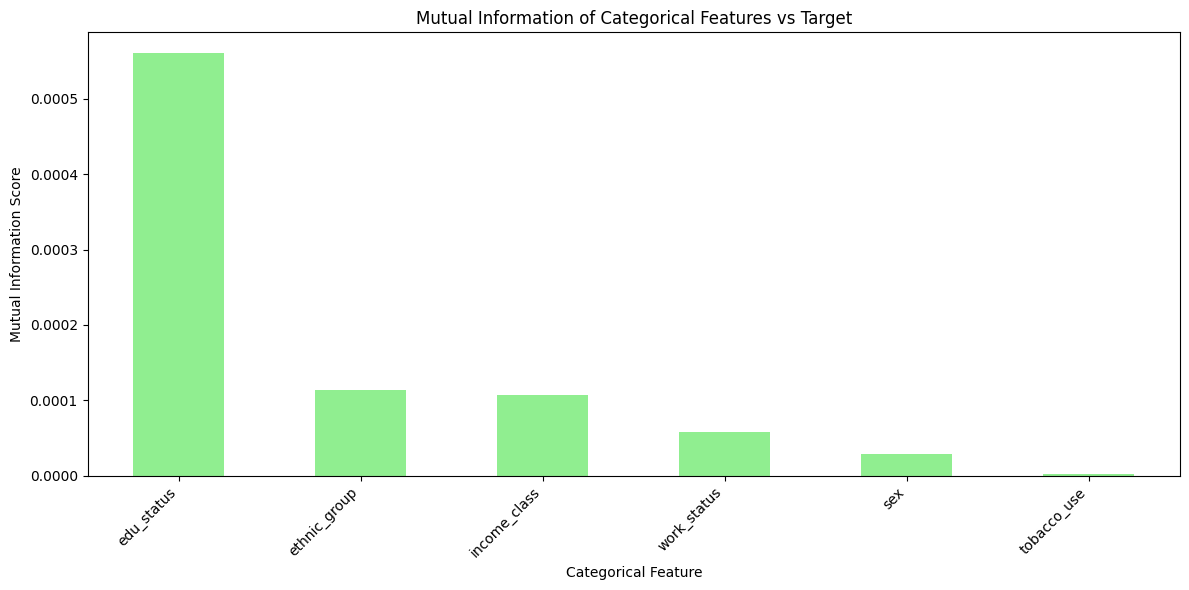

Top categorical features by MI: ['edu_status', 'ethnic_group', 'income_class', 'work_status', 'sex', 'tobacco_use']


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Copy dataset
train_df = X_train.copy()
train_df['Target'] = y_train

# Categorical features
cat_cols = train_df.select_dtypes(include=['object', 'category', 'bool']).columns
X_cat = train_df[cat_cols].copy()
print(cat_cols)

for col in X_cat.columns:
    if pd.api.types.is_categorical_dtype(X_cat[col]):
        # Add "Missing" as a category
        X_cat[col] = X_cat[col].cat.add_categories("Missing")
        
# Now fill missing values
X_cat.fillna("Missing", inplace=True)


X_cat = X_cat.astype(str)
# Encode categorical features numerically
encoder = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(encoder.fit_transform(X_cat), columns=cat_cols)


y = train_df['Target']

mi_scores_cat = mutual_info_classif(X_cat_encoded, y, discrete_features=True, random_state=42)
mi_cat_series = pd.Series(mi_scores_cat, index=cat_cols).sort_values(ascending=False)


plt.figure(figsize=(12,6))
mi_cat_series.plot(kind='bar', color='lightgreen')
plt.title("Mutual Information of Categorical Features vs Target")
plt.ylabel("Mutual Information Score")
plt.xlabel("Categorical Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Select top 6 categorical features
top_categorical = mi_cat_series.head(6).index.tolist()
print("Top categorical features by MI:", top_categorical)

In [ ]:
# List of low-MI columns
low_mi_cols = [
    'chol_ratio', 'count_whr', 'chol_squared', 'count_trig_level', 'count_body_mass_idx',
    'te_has_cardiovascular', 'te_total_chol', 'bp_category', 'nutrition_index', 'te_trig_level',
    'te_income_class', 'cholesterol_ratio', 'hypertension_stage', 'count_work_status',
    'count_ethnic_group', 'count_total_chol', 'hdl_chol', 'count_bp_diastolic', 'weekly_alcohol',
     'hypertension_flag', 'chol_hdl', 'te_has_hypertension', 'te_weekly_alcohol',
    'te_whr', 'whr', 'daily_screen_hrs', 'edu_status', 'count_nutrition_index', 'count_ldl_chol',
    'te_work_status', 'te_bp_diastolic', 'has_hypertension', 'te_hdl_chol', 'te_pulse_rate',
    'count_daily_screen_hrs', 'te_ethnic_group', 'te_body_mass_idx',
    'te_daily_screen_hrs', 'te_daily_sleep_hrs', 'te_nutrition_index', 'te_sex', 'te_tobacco_use',
    'te_edu_status', 'has_cardiovascular', 'work_status', 'count_has_cardiovascular',
    'count_has_hypertension', 'sex', 'tobacco_use', 'count_tobacco_use', 'count_weekly_alcohol',
    'income_class', 'count_sex', 'count_hdl_chol', 'count_daily_sleep_hrs', 'count_pulse_rate'
]

# Drop from X_train and X_test
X_train = X_train.drop(columns=[col for col in low_mi_cols if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in low_mi_cols if col in X_test.columns])

print("Shape of X_train after dropping low-MI columns:", X_train.shape)
print("Shape of X_test after dropping low-MI columns:", X_test.shape)


Shape of X_train after dropping low-MI columns: (18964, 39)
Shape of X_test after dropping low-MI columns: (4742, 39)


In [ ]:
X_train.shape

(18964, 37)

In [9]:
import pandas as pd
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

X_train shape: (476169, 59)
X_test shape: (119043, 59)


In [111]:
X_train_encoded.shape

(476169, 59)

In [ ]:

# =========================
# 4️⃣ Impute missing values
# =========================
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_ft),
                               columns=X_train_ft.columns, index=X_train_ft.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_ft),
                              columns=X_test_ft.columns, index=X_test_ft.index)

# =========================
# 5️⃣ Scale numeric features
# =========================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed),
                              columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed),
                             columns=X_test_imputed.columns, index=X_test_imputed.index)

# =========================
# 6️⃣ Train Random Forest
# =========================
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# =========================
# 7️⃣ Evaluate
# =========================
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Log Loss:", log_loss(y_test, y_pred_proba))

# =========================
# ✅ X_train_scaled and X_test_scaled now contain original + interaction features
# You can use them for any other model
# =========================


,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
id,,,,,,,,,,,,,,,,,,,,,
1265,C,27,No,No,No,No,No,40000.0,10000,30000,...,Never had,Never had,Never had,False,<NA>,NaN,NaN,False,NaN,NaN
5303,B,34,Don’t know or N/A,Don’t know or N/A,No,Don't know,Yes,97.0,300,97,...,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,False,Never had,Never had
4512,D,39,Yes,Yes,No,Yes,No,2500.0,4800,288000,...,NaN,NaN,NaN,False,0,Never had,Have now,<NA>,NaN,NaN
7452,D,38,No,Yes,No,Don't know,Don't know,500.0,5400,7200,...,NaN,NaN,NaN,True,2,Never had,Have now,<NA>,NaN,NaN
5765,C,36,Don’t know or N/A,No,No,Don't know,Don't know,700000.0,17000,8400000,...,Never had,Never had,Used to have but don't have now,True,<NA>,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2344,D,27,Yes,Yes,No,Don't know,No,30.0,1080,1800,...,NaN,NaN,NaN,False,11,Never had,Have now,True,NaN,NaN
9076,D,52,Yes,No,No,No,Yes,NaN,300,2500,...,NaN,NaN,NaN,True,8,Never had,Never had,<NA>,NaN,NaN
5343,A,43,No,No,No,No,Yes,600.0,1000,2500,...,Have now,Never had,Never had,<NA>,8,Never had,Have now,<NA>,Never had,Never had


## AutoFeat

In [ ]:
import pandas as pd
from autofeat import AutoFeatClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss

# 1️⃣ Prepare features and target
X = df.drop(columns=['Target', 'ID', 'id'])
y = df['Target'].map({'Low':0, 'Medium':1, 'High':2})

# 2️⃣ Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3️⃣ Identify numeric and categorical
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 4️⃣ Impute missing values
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# 5️⃣ Encode categorical as integers
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# 6️⃣ Apply AutoFeat
af_clf = AutoFeatClassifier(verbose=1, feateng_steps=2)
X_train_af = af_clf.fit_transform(X_train, y_train)
X_test_af = af_clf.transform(X_test)




2025-12-27 00:47:55,958 INFO: [AutoFeat] The 2 step feature engineering process could generate up to 33670 features.
2025-12-27 00:47:55,959 INFO: [AutoFeat] With 7694 data points this new feature matrix would use about 1.04 gb of space.
2025-12-27 00:47:55,965 INFO: [feateng] Step 1: transformation of original features


2025-12-27 00:47:58,516 INFO: [feateng] Generated 110 transformed features from 37 original features - done.
2025-12-27 00:47:58,520 INFO: [feateng] Step 2: first combination of features


2025-12-27 00:48:06,529 INFO: [feateng] Generated 10701 feature combinations from 10731 original feature tuples - done.


2025-12-27 00:48:08,668 INFO: [feateng] Generated altogether 10841 new features in 2 steps
2025-12-27 00:48:08,669 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2025-12-27 00:48:19,499 INFO: [feateng] Generated a total of 7782 additional features


[featsel] Scaling data...

2025-12-27 00:48:23,896 INFO: [featsel] Feature selection run 1/5


done.


In [ ]:

# Train a simple classifier on AutoFeat features
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_transformed, y_train)

# Evaluate
y_pred = rf_model.predict(X_test_transformed)
y_pred_proba = rf_model.predict_proba(X_test_transformed)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_pred_proba))
